# 🧠 Stroke Prediction — EDA & Data Processing

<div align="center">
  <img src="https://img.icons8.com/color/96/000000/brain.png" width="60"/>
</div>

<br>

<span style="font-size:1.1em;">
Este notebook reorganiza el análisis de predicción de ACV (stroke) en un flujo profesional, visual y didáctico. Se mantiene el contenido analítico, pero se mejora la presentación y claridad.
</span>

---

## 🎯 Objetivos

- **Carga y partición** del dataset en entrenamiento y validación.
- **EDA** (análisis exploratorio) solo sobre el set de entrenamiento.
- Análisis de **valores faltantes** y la categoría `"Unknown"` en `smoking_status`.
- Preprocesamiento seguro contra *leakage*.
- Construcción de matrices de features procesadas para modelado.
- Estudio de la asociación entre variables y el target usando métricas lineales y no lineales.

<br>
<details>
<summary>ℹ️ <b>Tips para navegar este notebook</b></summary>

- Las secciones están claramente marcadas y cada bloque de código incluye comentarios aclaratorios.
- Se utilizan gráficos y tablas para facilitar la interpretación.
- Al final de cada sección clave encontrarás conclusiones o recomendaciones.
</details>


## 1. ⚙️ Setup y carga de datos

> En esta sección se importan las librerías necesarias y se carga el dataset. Además, se configuran opciones visuales para que los gráficos y tablas sean más claros y agradables.


In [359]:
# 📦 Importación de librerías y configuración visual
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split



In [360]:
# Mejoras visuales para pandas y matplotlib
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = False
sns.set_palette("Set2")  # Paleta de colores amigable
sns.set_style("whitegrid")


# 📂 Carga del dataset
df = pd.read_csv("../datasets/healthcare-dataset-stroke-data.csv")
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [361]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [362]:
df = df.drop(columns=['id'])

In [363]:
df['stroke'].value_counts()  # desbalance

stroke
0    4861
1     249
Name: count, dtype: int64

In [364]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [365]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### Distribución del target

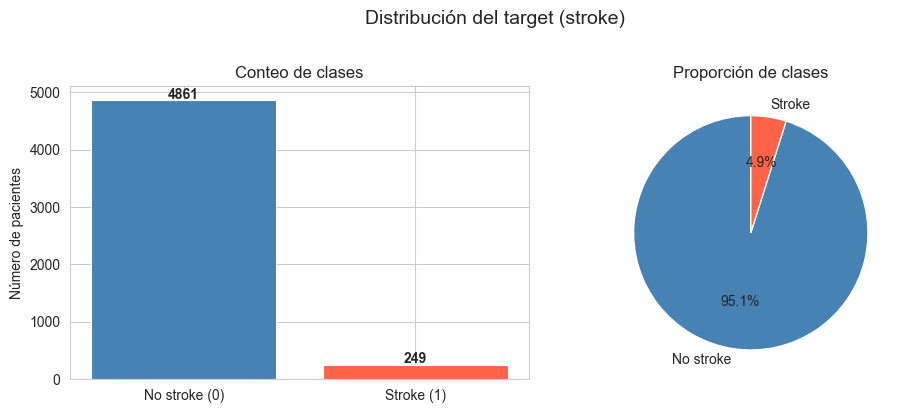

Ratio de desbalanceo: 19.5:1


In [366]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo absoluto
counts = df["stroke"].value_counts()
axes[0].bar(["No stroke (0)", "Stroke (1)"], counts.values,
            color=["steelblue", "tomato"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Conteo de clases")
axes[0].set_ylabel("Número de pacientes")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Proporción
axes[1].pie(counts.values, labels=["No stroke", "Stroke"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporción de clases")

plt.suptitle("Distribución del target (stroke)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Ratio de desbalanceo: {counts[0]/counts[1]:.1f}:1")

### Nulos
Única columna con nulos es BMI

In [367]:
# Explorar si los nulos de bmi tienen algún patrón
print("Distribución de stroke en filas CON nulos en bmi:")
print(df[df["bmi"].isnull()]["stroke"].value_counts(normalize=True).round(3))
print("\nDistribución de stroke en filas SIN nulos:")
print(df[df["bmi"].notna()]["stroke"].value_counts(normalize=True).round(3))

Distribución de stroke en filas CON nulos en bmi:
stroke
0    0.801
1    0.199
Name: proportion, dtype: float64

Distribución de stroke en filas SIN nulos:
stroke
0    0.957
1    0.043
Name: proportion, dtype: float64


## 2. ✂️ Train / validation split

> Se separa el dataset en entrenamiento y validación, manteniendo la proporción de la variable objetivo (*stratified split*). Esto es clave para evitar sesgos y asegurar una evaluación justa del modelo.


In [368]:
# ---
# 🔀 Split de datos en entrenamiento y validación
# Se utiliza stratify para mantener la proporción de casos de stroke en ambos sets
X = df.drop(columns="stroke")
y = df["stroke"].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

split_summary = pd.DataFrame({
    "set": ["Train", "Validation"],
    "rows": [len(X_train), len(X_val)],
    "stroke_rate (%)": [
        round(y_train.mean() * 100, 2),
        round(y_val.mean() * 100, 2)
    ]
})

print("Split summary:")
display(split_summary)


Split summary:


,set,rows,stroke_rate (%)
0,Train,3577,4.86
1,Validation,1533,4.89


In [369]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3577 entries, 2226 to 5052
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             3577 non-null   object 
 1   age                3577 non-null   float64
 2   hypertension       3577 non-null   int64  
 3   heart_disease      3577 non-null   int64  
 4   ever_married       3577 non-null   object 
 5   work_type          3577 non-null   object 
 6   Residence_type     3577 non-null   object 
 7   avg_glucose_level  3577 non-null   float64
 8   bmi                3429 non-null   float64
 9   smoking_status     3577 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 307.4+ KB


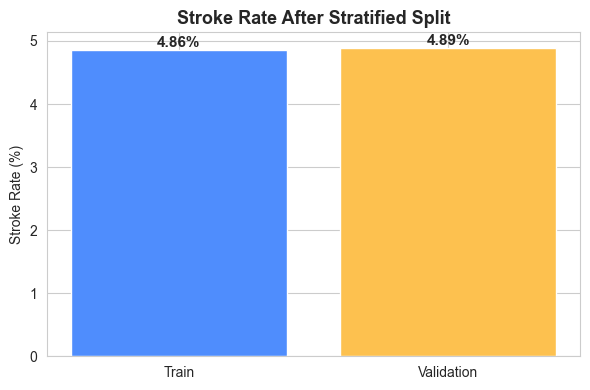


🔎 KEY OBSERVATIONS
- Train size: 3577 | Validation size: 1533
- Stroke rate (train): 4.86%
- Stroke rate (validation): 4.89%
- El split estratificado preserva la distribución de clases en ambos sets.


In [370]:
# ---
# 📊 Visualización de la proporción de stroke tras el split
plt.figure(figsize=(6, 4))

train_val_rates = [y_train.mean() * 100, y_val.mean() * 100]
labels = ["Train", "Validation"]

bars = plt.bar(labels, train_val_rates, color=["#4F8DFD", "#FDC14F"])
plt.title("Stroke Rate After Stratified Split", fontsize=13, fontweight="bold")
plt.ylabel("Stroke Rate (%)")

for bar, val in zip(bars, train_val_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("🔎 KEY OBSERVATIONS")
print("=" * 60)
print(f"- Train size: {len(X_train)} | Validation size: {len(X_val)}")
print(f"- Stroke rate (train): {y_train.mean()*100:.2f}%")
print(f"- Stroke rate (validation): {y_val.mean()*100:.2f}%")
print("- El split estratificado preserva la distribución de clases en ambos sets.")


## 3. 🧩 Tipado de variables y EDA sobre entrenamiento

> Todo el análisis exploratorio se realiza **solo sobre el set de entrenamiento** para evitar *leakage* de información hacia la validación.


In [371]:
# Feature typing
num_cols = ["age", "avg_glucose_level", "bmi"]

cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status", "hypertension", "heart_disease"]

print("Numerical variables:", num_cols)
print("Categorical variables:", cat_cols)

Numerical variables: ['age', 'avg_glucose_level', 'bmi']
Categorical variables: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease']


### 3.1 Numerical variables — distributions and outliers

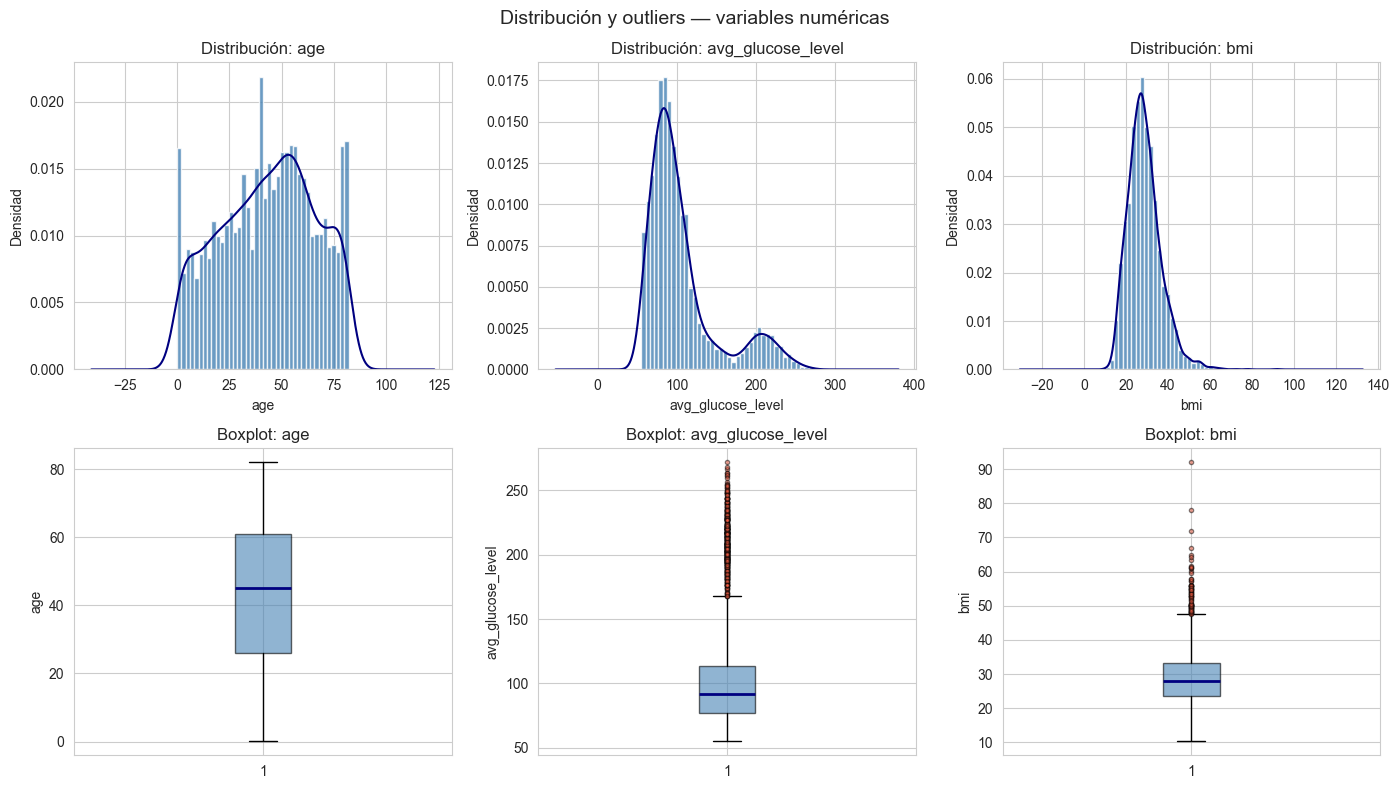

age                  → skewness: -0.143
avg_glucose_level    → skewness: 1.584
bmi                  → skewness: 1.037


In [372]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    # Histograma + KDE
    axes[0, i].hist(X_train[col].dropna(), bins=40, color="steelblue",
                    edgecolor="white", alpha=0.8, density=True)
    X_train[col].dropna().plot(kind="kde", ax=axes[0, i], color="navy", linewidth=1.5)
    axes[0, i].set_title(f"Distribución: {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Densidad")

    # Boxplot para detectar outliers
    axes[1, i].boxplot(X_train[col].dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor="steelblue", alpha=0.6),
                       medianprops=dict(color="navy", linewidth=2),
                       flierprops=dict(marker="o", markersize=3,
                                       markerfacecolor="tomato", alpha=0.5))
    axes[1, i].set_title(f"Boxplot: {col}")
    axes[1, i].set_ylabel(col)

plt.suptitle("Distribución y outliers — variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

# Estadísticas de skewness
for col in num_cols:
    skew = X_train[col].skew()
    print(f"{col:20s} → skewness: {skew:.3f}")

### 3.2 Categorical variables — distributions

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_23268/2373118661.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x=col, order=order, ax=axes[i],
/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_23268/2373118661.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x=col, order=order, ax=axes[i],
/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_23268/2373118661.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x=col, order=order, ax=axes[i],
/var/folders/6s/4bx

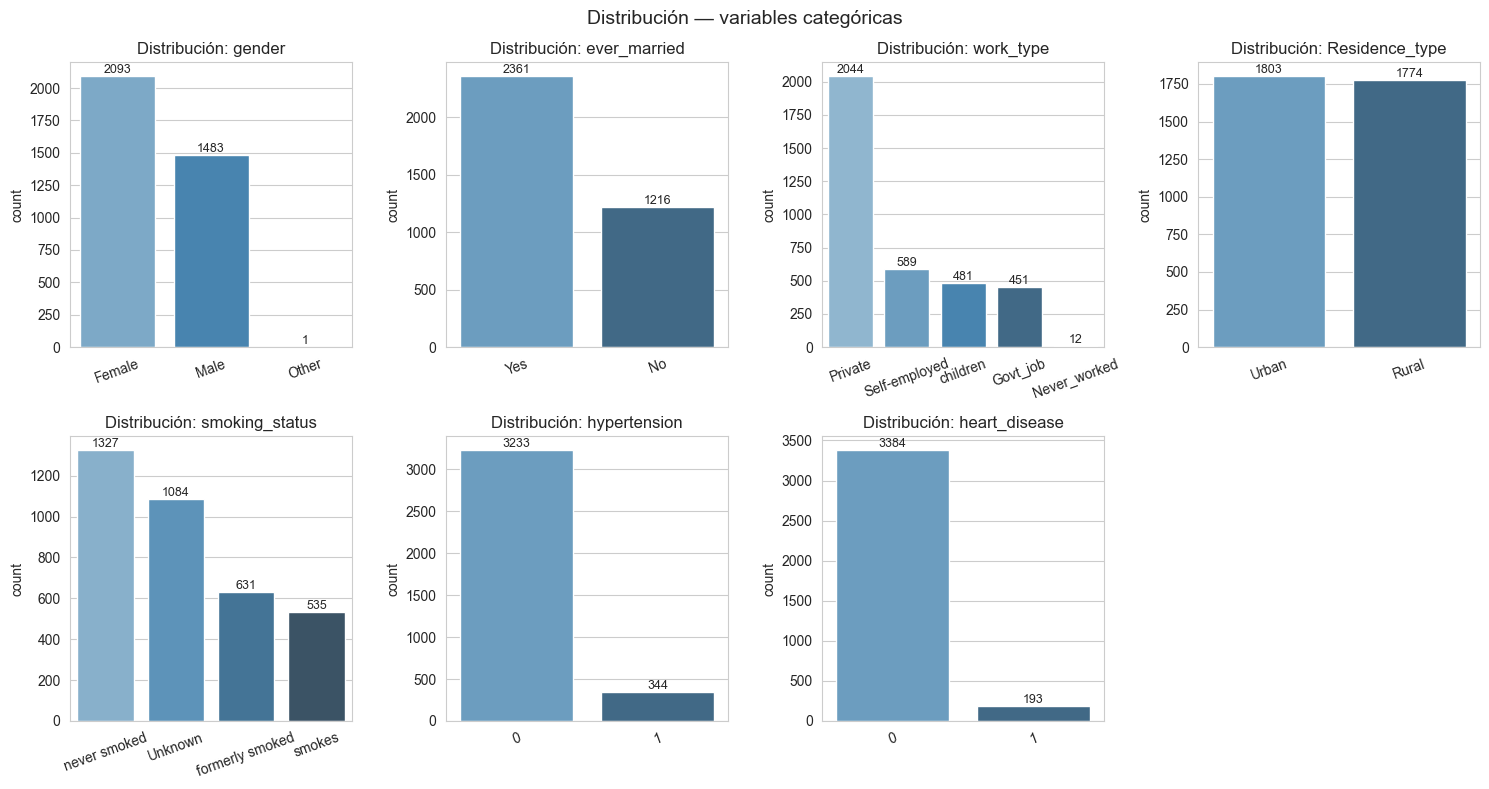

In [373]:

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = X_train[col].value_counts().index
    sns.countplot(data=X_train, x=col, order=order, ax=axes[i],
                  palette="Blues_d", edgecolor="white")
    axes[i].set_title(f"Distribución: {col}")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=20)
    # Anotar conteos
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}",
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha="center", va="bottom", fontsize=9)

axes[-1].set_visible(False)  # Ocultar el subplot sobrante
plt.suptitle("Distribución — variables categóricas", fontsize=14)
plt.tight_layout()
plt.show()

### 3.3 Variables vs target on the training set

Variables numericas

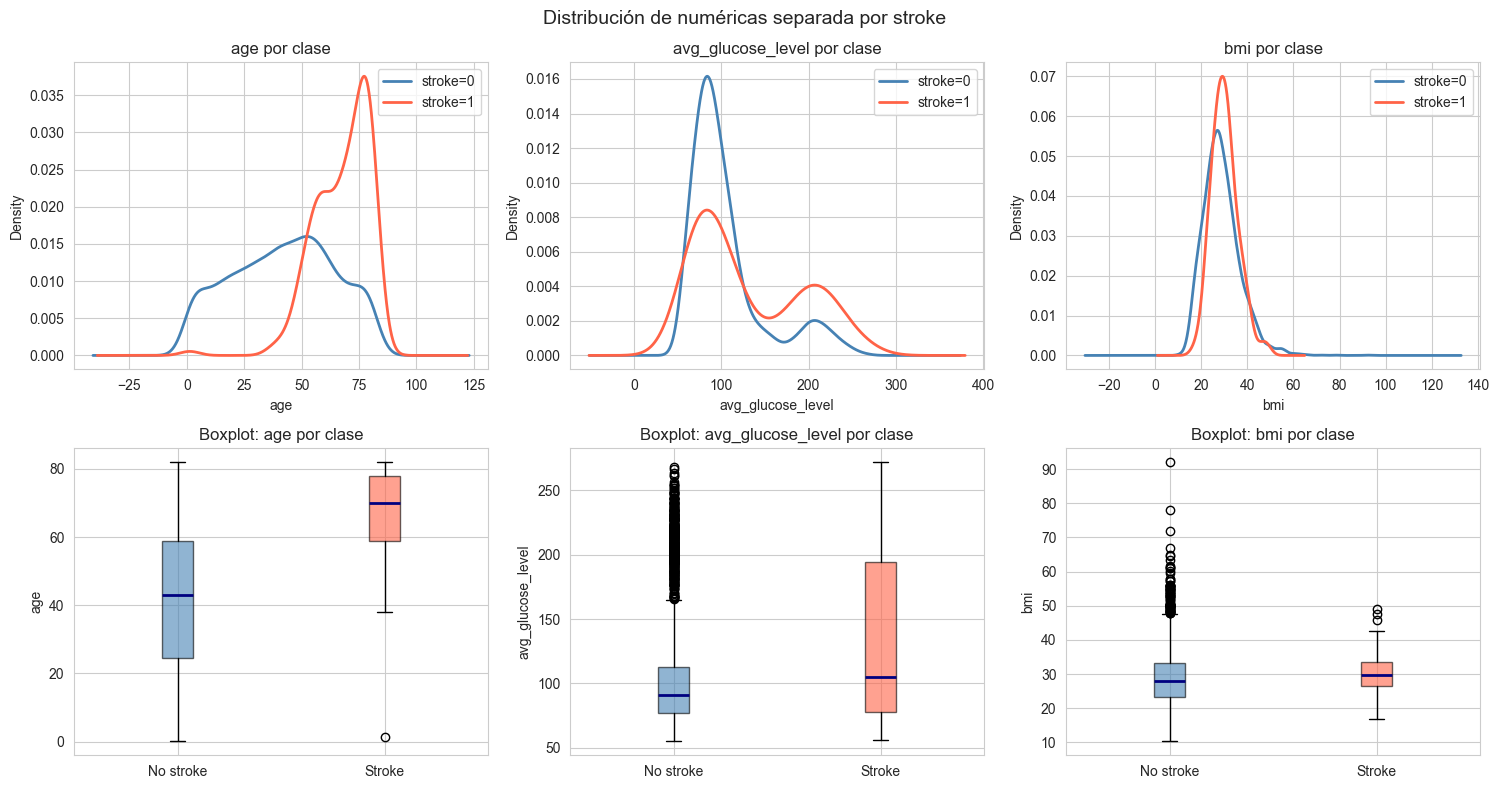

In [374]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # KDE separado por clase
    for label, color in zip([0, 1], ["steelblue", "tomato"]):
        subset = X_train[y_train == label][col].dropna()
        subset.plot(kind="kde", ax=axes[0, i], label=f"stroke={label}",
                    color=color, linewidth=2)
    axes[0, i].set_title(f"{col} por clase")
    axes[0, i].set_xlabel(col)
    axes[0, i].legend()

    # Boxplot por clase
    data_by_class = [X_train[y_train == lbl][col].dropna() for lbl in [0, 1]]
    bp = axes[1, i].boxplot(data_by_class, labels=["No stroke", "Stroke"],
                            patch_artist=True,
                            medianprops=dict(color="navy", linewidth=2))
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor("tomato")
    bp["boxes"][1].set_alpha(0.6)
    axes[1, i].set_title(f"Boxplot: {col} por clase")
    axes[1, i].set_ylabel(col)

plt.suptitle("Distribución de numéricas separada por stroke", fontsize=14)
plt.tight_layout()
plt.show()

- Age vs stroke: Claramente desplazado hacia edades más altas. La edad es el predictor más fuerte del dataset.
- Nivel de glucosa vs stroke: casos de stroke = 1 tiene mayor densida en valores altos de glucosa.
- BMI vs stroke: No es un predictor fuerte del dataset.

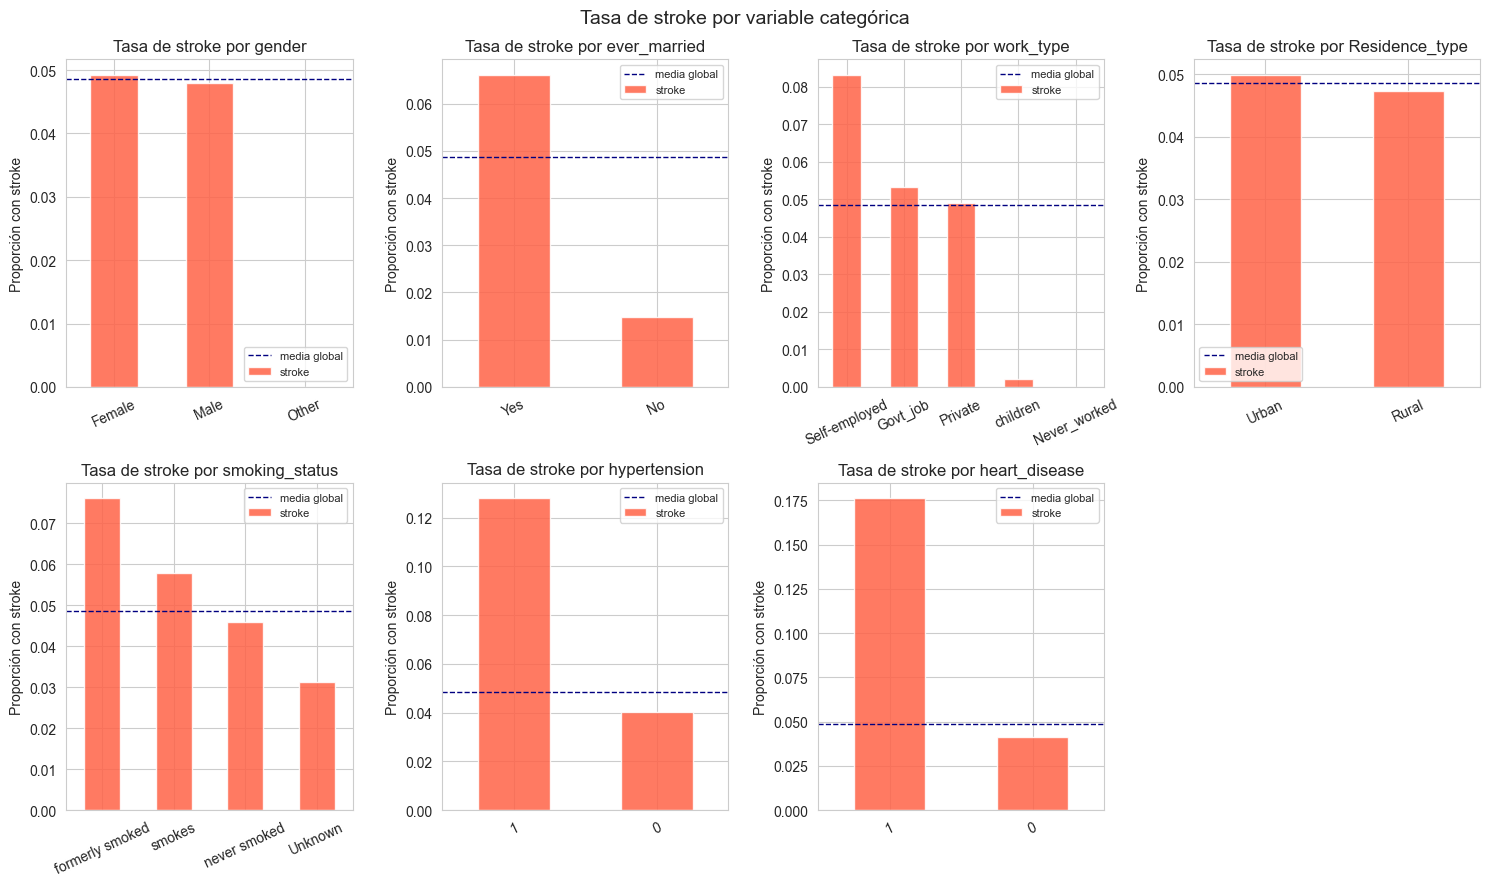

In [375]:
# --- Categóricas vs target: tasa de stroke por categoría ---
fig, axes = plt.subplots(2, 4, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    stroke_rate = y_train.groupby(X_train[col]).mean().sort_values(ascending=False)  
    stroke_rate.plot(kind="bar", ax=axes[i], color="tomato",
                     edgecolor="white", alpha=0.85)
    axes[i].set_title(f"Tasa de stroke por {col}")
    axes[i].set_ylabel("Proporción con stroke")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].axhline(y_train.mean(), color="navy",
                    linestyle="--", linewidth=1, label="media global")
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Tasa de stroke por variable categórica", fontsize=14)
plt.tight_layout()
plt.show()

- Hypertension y heart_disease tienen una tasa de stroke notablemente más altas que la media global.
- smoking_status con el valor de formerly_smoked tambien cuenta una tasa de stroke un poco mas alta que la media global.
- work_type con el valor de self_employed tambien presenta una tasa de stroke un poco mas alta que la media global.

### Correlaciones entre features

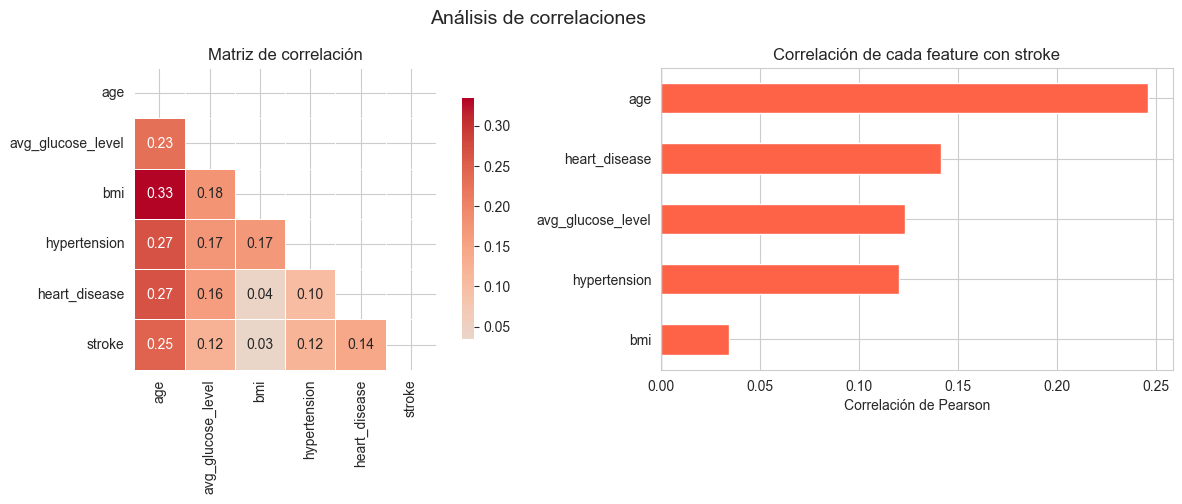

In [376]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))                                                                                 
                                                                                                                                                                                                                                                   
train_df = X_train[["age", "avg_glucose_level", "bmi", "hypertension",                                                                                                                                                                           
                    "heart_disease"]].copy()                                                                                                                                                                                                    
train_df["stroke"] = y_train.values                                                                                                                                                                                                              
                                                                                                                                                                                                                                                
corr = train_df.corr()
                                                                                                                                                                                                                                                
mask = np.triu(np.ones_like(corr, dtype=bool))            
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0], square=True,                                                                                                                                                                                                   
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_title("Matriz de correlación")                                                                                                                                                                                                       
                                                                                                                                                                                                                                                
target_corr = corr["stroke"].drop("stroke").sort_values(key=abs, ascending=True)
target_corr.plot(kind="barh", ax=axes[1],                                                                                                                                                                                                        
                color=["tomato" if v > 0 else "steelblue" for v in target_corr],
                edgecolor="white")                                                                                                                                                                                                              
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación de cada feature con stroke")                                                                                                                                                                                      
axes[1].set_xlabel("Correlación de Pearson")              
                                                                                                                                                                                                                                                
plt.suptitle("Análisis de correlaciones", fontsize=14)
plt.tight_layout()                                                                                                                                                                                                                               
plt.show()

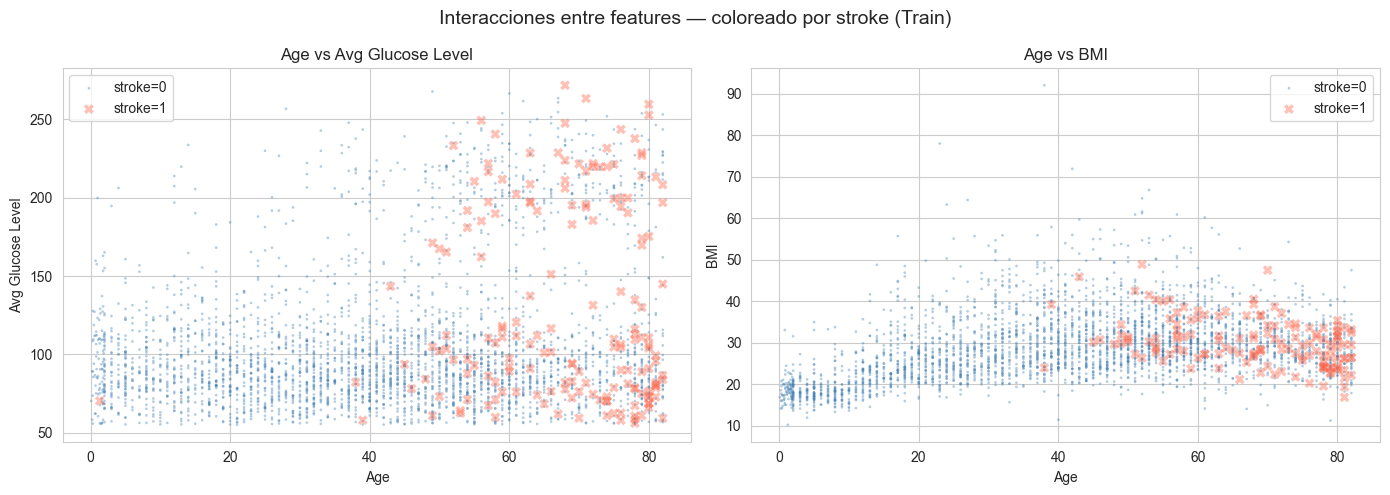

Observaciones:
  - Los casos de stroke se concentran en edades mayores (>40 años)
  - Glucosa alta + edad avanzada parece ser un patrón frecuente en stroke
  - El BMI solo no discrimina bien, pero combinado con edad aporta información


In [377]:
# --- Interacciones clave entre features (Train) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs Avg Glucose Level
for label, color, marker in zip([0, 1], ["steelblue", "tomato"], [".", "X"]):
    subset = X_train[y_train == label]
    axes[0].scatter(subset["age"], subset["avg_glucose_level"],
                    c=color, label=f"stroke={label}", alpha=0.4,
                    s=15 if label == 0 else 50, marker=marker, edgecolors="none")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Avg Glucose Level")
axes[0].set_title("Age vs Avg Glucose Level")
axes[0].legend()

# Age vs BMI
for label, color, marker in zip([0, 1], ["steelblue", "tomato"], [".", "X"]):
    subset = X_train[y_train == label]
    axes[1].scatter(subset["age"], subset["bmi"],
                    c=color, label=f"stroke={label}", alpha=0.4,
                    s=15 if label == 0 else 50, marker=marker, edgecolors="none")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("BMI")
axes[1].set_title("Age vs BMI")
axes[1].legend()

plt.suptitle("Interacciones entre features — coloreado por stroke (Train)", fontsize=14)
plt.tight_layout()
plt.show()

print("Observaciones:")
print("  - Los casos de stroke se concentran en edades mayores (>40 años)")
print("  - Glucosa alta + edad avanzada parece ser un patrón frecuente en stroke")
print("  - El BMI solo no discrimina bien, pero combinado con edad aporta información")

- Age presenta la correlación más alta con stroke. Al mismo tiempo presenta una correlación alta con hypertension y heart_disease. Lo que indica cierta multicolinealidad entre features. 

## 4. Focused analysis of `smoking_status = "Unknown"`

This section explores whether `"Unknown"` behaves like a distinct category or could be grouped with another smoking category.


In [378]:
# --- Proporción y conteo de Unknown en train ---
smoking_counts = X_train["smoking_status"].value_counts()
smoking_pct = X_train["smoking_status"].value_counts(normalize=True)

summary_smoking = pd.DataFrame({"conteo": smoking_counts, "proporción": smoking_pct.round(4)})
display(summary_smoking)

n_unknown = (X_train["smoking_status"] == "Unknown").sum()
print(f"\n'Unknown' representa {n_unknown} filas ({n_unknown/len(X_train):.1%} del train set)")
print(f"No es un nulo técnico (no aparece en isnull), sino un valor explícito del dataset.")

,conteo,proporción
smoking_status,,
never smoked,1327,0.3710
Unknown,1084,0.3030
formerly smoked,631,0.1764
smokes,535,0.1496



'Unknown' representa 1084 filas (30.3% del train set)
No es un nulo técnico (no aparece en isnull), sino un valor explícito del dataset.


/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_23268/151067315.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_train, x="smoking_status", y="age", ax=axes[0, 0],


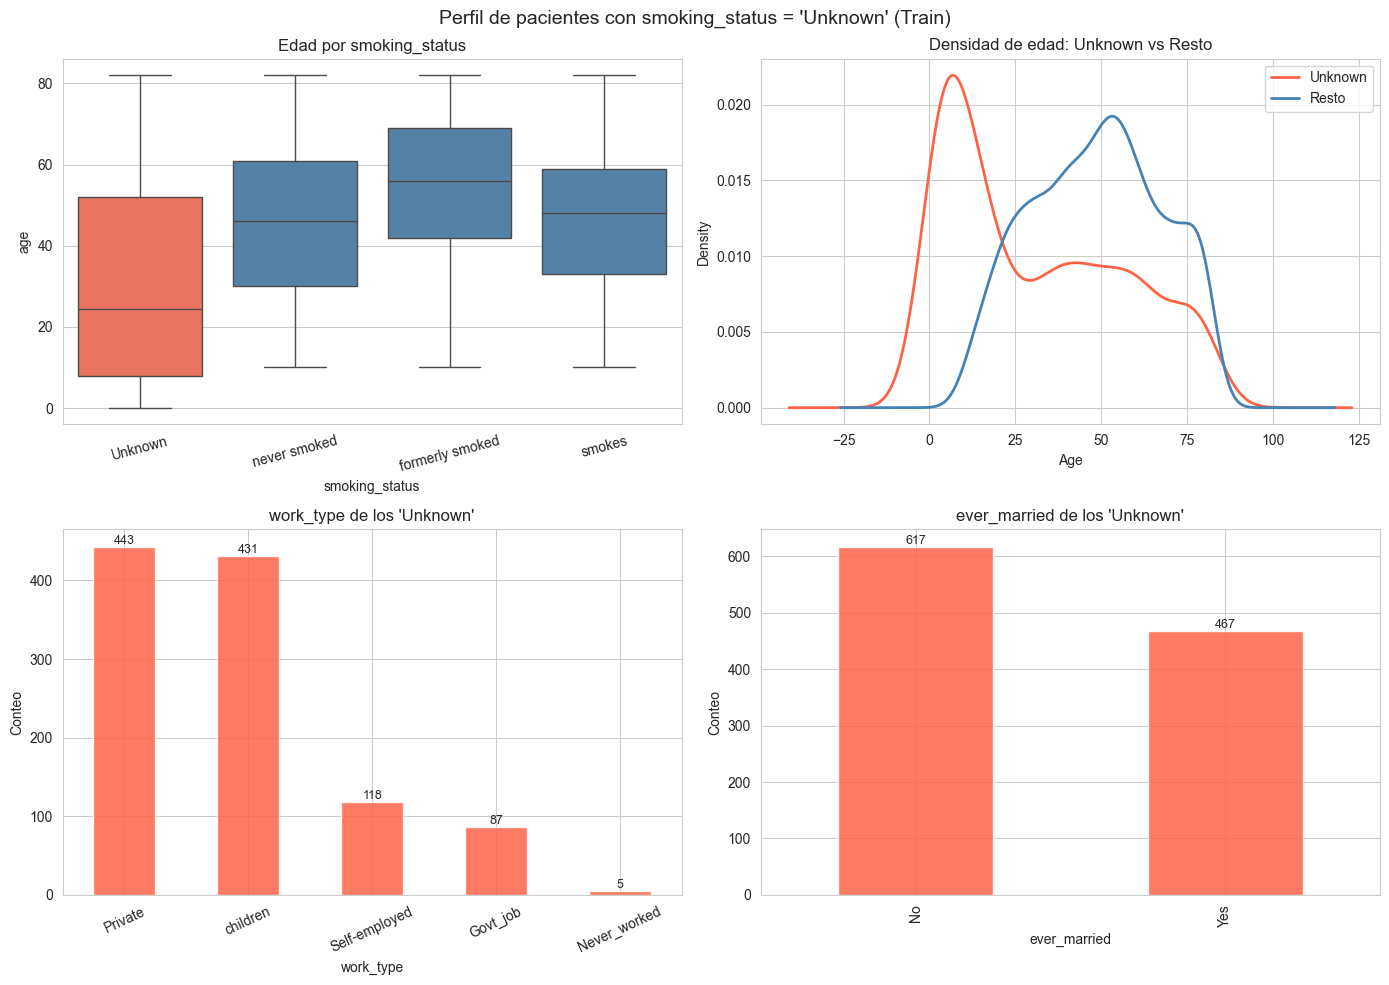

Edad media por smoking_status:
                 mean  median   min   max
smoking_status                           
Unknown          30.8    24.5   0.1  82.0
formerly smoked  54.2    56.0  10.0  82.0
never smoked     46.5    46.0  10.0  82.0
smokes           47.5    48.0  10.0  82.0

% de menores de 18 años dentro de Unknown: 43.5%


In [379]:
# --- Perfil demográfico de Unknown vs otras categorías ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de edad por smoking_status
sns.boxplot(data=X_train, x="smoking_status", y="age", ax=axes[0, 0],
            order=["Unknown", "never smoked", "formerly smoked", "smokes"],
            palette={"Unknown": "tomato", "never smoked": "steelblue",
                     "formerly smoked": "steelblue", "smokes": "steelblue"})
axes[0, 0].set_title("Edad por smoking_status")
axes[0, 0].tick_params(axis="x", rotation=15)

# 2. Distribución de edad: KDE Unknown vs resto
X_train[X_train["smoking_status"] == "Unknown"]["age"].plot(
    kind="kde", ax=axes[0, 1], label="Unknown", color="tomato", linewidth=2)
X_train[X_train["smoking_status"] != "Unknown"]["age"].plot(
    kind="kde", ax=axes[0, 1], label="Resto", color="steelblue", linewidth=2)
axes[0, 1].set_title("Densidad de edad: Unknown vs Resto")
axes[0, 1].set_xlabel("Age")
axes[0, 1].legend()

# 3. Work type dentro de Unknown
unknown_work = X_train[X_train["smoking_status"] == "Unknown"]["work_type"].value_counts()
unknown_work.plot(kind="bar", ax=axes[1, 0], color="tomato", edgecolor="white", alpha=0.85)
axes[1, 0].set_title("work_type de los 'Unknown'")
axes[1, 0].set_ylabel("Conteo")
axes[1, 0].tick_params(axis="x", rotation=25)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{int(p.get_height())}",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

# 4. ever_married dentro de Unknown
unknown_married = X_train[X_train["smoking_status"] == "Unknown"]["ever_married"].value_counts()
unknown_married.plot(kind="bar", ax=axes[1, 1], color="tomato", edgecolor="white", alpha=0.85)
axes[1, 1].set_title("ever_married de los 'Unknown'")
axes[1, 1].set_ylabel("Conteo")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{int(p.get_height())}",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

plt.suptitle("Perfil de pacientes con smoking_status = 'Unknown' (Train)", fontsize=14)
plt.tight_layout()
plt.show()

# Estadísticas numéricas
print("Edad media por smoking_status:")
print(X_train.groupby("smoking_status")["age"].agg(["mean", "median", "min", "max"]).round(1))
print(f"\n% de menores de 18 años dentro de Unknown: "
      f"{(X_train[X_train['smoking_status']=='Unknown']['age'] < 18).mean():.1%}")

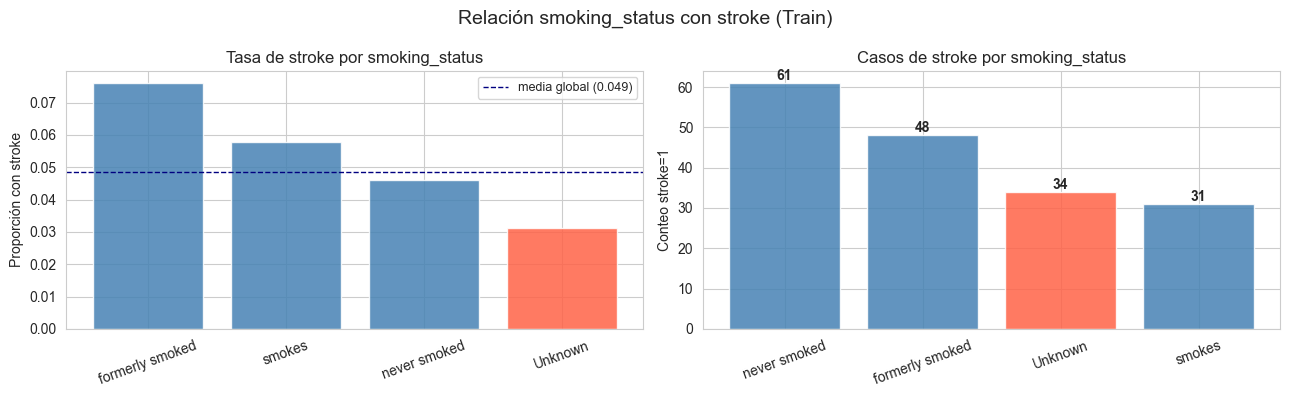

Tasa de stroke y conteo por categoría:


,tasa_stroke,n_stroke,n_total
smoking_status,,,
formerly smoked,0.076070,48,631
smokes,0.057944,31,535
never smoked,0.045968,61,1327
Unknown,0.031365,34,1084


In [380]:
# --- Tasa de stroke: Unknown vs otras categorías ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tasa de stroke por smoking_status
stroke_by_smoking = y_train.groupby(X_train["smoking_status"]).agg(["mean", "count"])
stroke_by_smoking = stroke_by_smoking.sort_values("mean", ascending=False)

colors = ["tomato" if idx == "Unknown" else "steelblue" for idx in stroke_by_smoking.index]
axes[0].bar(stroke_by_smoking.index, stroke_by_smoking["mean"], color=colors,
            edgecolor="white", alpha=0.85)
axes[0].axhline(y_train.mean(), color="navy", linestyle="--",
                linewidth=1, label=f"media global ({y_train.mean():.3f})")
axes[0].set_title("Tasa de stroke por smoking_status")
axes[0].set_ylabel("Proporción con stroke")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=9)

# Conteo de stroke=1 por smoking_status
stroke_counts = X_train[y_train == 1]["smoking_status"].value_counts()
colors2 = ["tomato" if idx == "Unknown" else "steelblue" for idx in stroke_counts.index]
axes[1].bar(stroke_counts.index, stroke_counts.values, color=colors2,
            edgecolor="white", alpha=0.85)
axes[1].set_title("Casos de stroke por smoking_status")
axes[1].set_ylabel("Conteo stroke=1")
axes[1].tick_params(axis="x", rotation=20)
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("Relación smoking_status con stroke (Train)", fontsize=14)
plt.tight_layout()
plt.show()

print("Tasa de stroke y conteo por categoría:")
display(y_train.groupby(X_train["smoking_status"]).agg(["mean", "sum", "count"])
        .rename(columns={"mean": "tasa_stroke", "sum": "n_stroke", "count": "n_total"})
        .sort_values("tasa_stroke", ascending=False))

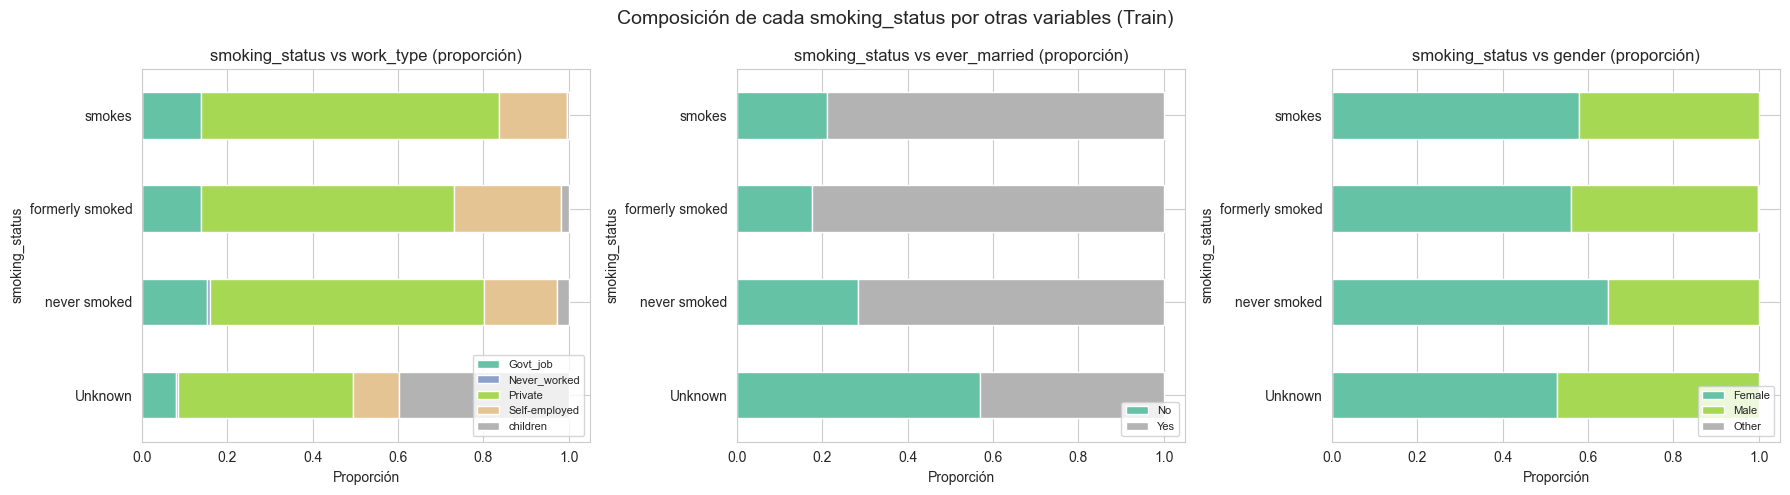

In [381]:
# --- Crosstab: smoking_status vs otras categóricas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["work_type", "ever_married", "gender"]):
    ct = pd.crosstab(X_train["smoking_status"], X_train[col], normalize="index")
    ct.loc[["Unknown", "never smoked", "formerly smoked", "smokes"]].plot(
        kind="barh", stacked=True, ax=ax, colormap="Set2", edgecolor="white")
    ax.set_title(f"smoking_status vs {col} (proporción)")
    ax.set_xlabel("Proporción")
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Composición de cada smoking_status por otras variables (Train)", fontsize=14)
plt.tight_layout()
plt.show()

In [382]:
# --- Resumen: ¿quiénes son los Unknown? ---
unknown = X_train[X_train["smoking_status"] == "Unknown"]
known = X_train[X_train["smoking_status"] != "Unknown"]
y_unknown = y_train[X_train["smoking_status"] == "Unknown"]
y_known = y_train[X_train["smoking_status"] != "Unknown"]

resumen = pd.DataFrame({
    "Unknown": [
        len(unknown),
        unknown["age"].mean(),
        unknown["age"].median(),
        (unknown["age"] < 18).mean(),
        (unknown["work_type"] == "children").mean(),
        (unknown["ever_married"] == "No").mean(),
        y_unknown.mean(),
    ],
    "Resto": [
        len(known),
        known["age"].mean(),
        known["age"].median(),
        (known["age"] < 18).mean(),
        (known["work_type"] == "children").mean(),
        (known["ever_married"] == "No").mean(),
        y_known.mean(),
    ]
}, index=["N", "Edad media", "Edad mediana", "% menores 18",
          "% work_type=children", "% ever_married=No", "Tasa de stroke"])

display(resumen.round(4))


,Unknown,Resto
N,1084.0000,2493.0000
Edad media,30.8448,48.6446
Edad mediana,24.5000,49.0000
% menores 18,0.4354,0.0449
% work_type=children,0.3976,0.0201
% ever_married=No,0.5692,0.2403
Tasa de stroke,0.0314,0.0562



- Los 'Unknown' son mayoritariamente personas jóvenes (niños/adolescentes). Muchos tienen work_type='children' y ever_married='No'
- Su baja tasa de stroke se explica por la edad, no por el hábito de fumar
- 'Unknown' NO es dato faltante aleatorio (MCAR), sino sistemático (MAR). Está asociado a la edad del paciente

Opciones de tratamiento:
- Mantener 'Unknown' como categoría propia. Refleja información real, no aplica.
- Reemplazar por 'never smoked' en menores de 18 y dejar Unknown en adultos
- Imputar con modelo predictivo basado en age, work_type, ever_married

### Preprocessing decision for `smoking_status`

The working decision retained from the original notebook is to replace `"Unknown"` with `"never smoked"` in both training and validation sets.


In [383]:
# Smoking_status replacement
X_train["smoking_status"] = X_train["smoking_status"].replace("Unknown", "never smoked")
X_val["smoking_status"] = X_val["smoking_status"].replace("Unknown", "never smoked")

## 5. Análisis de valores faltantes en `bmi`

In [384]:
# --- Proporción y conteo de nulos en BMI ---
bmi_missing = X_train["bmi"].isnull()
n_missing = bmi_missing.sum()
pct_missing = bmi_missing.mean() * 100

print(f"BMI faltante: {n_missing} filas ({pct_missing:.2f}% del train set)")
print(f"BMI presente: {(~bmi_missing).sum()} filas ({100 - pct_missing:.2f}%)")
print(f"\nEs la única columna con nulos en el dataset.")

BMI faltante: 148 filas (4.14% del train set)
BMI presente: 3429 filas (95.86%)

Es la única columna con nulos en el dataset.


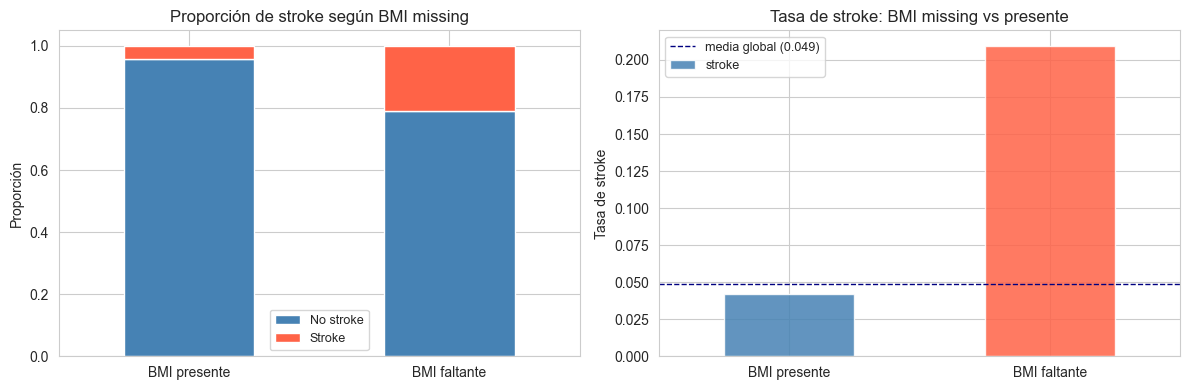

Tasa de stroke por grupo:
  BMI presente: 0.0417
  BMI faltante: 0.2095


In [385]:
# --- ¿Los nulos de BMI están asociados al target? ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bmi_missing_flag = X_train["bmi"].isnull().astype(int)

# 1. Crosstab normalizado
ctab = pd.crosstab(bmi_missing_flag, y_train, normalize="index")
ctab.index = ["BMI presente", "BMI faltante"]
ctab = ctab.rename(columns={0: "No stroke", 1: "Stroke"})
ctab.plot(kind="bar", stacked=True, ax=axes[0],
          color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_title("Proporción de stroke según BMI missing")
axes[0].set_ylabel("Proporción")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=9)

# 2. Tasa de stroke: missing vs presente
stroke_rate = y_train.groupby(bmi_missing_flag).mean()
stroke_rate.index = ["BMI presente", "BMI faltante"]
colors = ["steelblue", "tomato"]
stroke_rate.plot(kind="bar", ax=axes[1], color=colors, edgecolor="white", alpha=0.85)
axes[1].axhline(y_train.mean(), color="navy", linestyle="--",
                linewidth=1, label=f"media global ({y_train.mean():.3f})")
axes[1].set_title("Tasa de stroke: BMI missing vs presente")
axes[1].set_ylabel("Tasa de stroke")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Tasa de stroke por grupo:")
print(f"  BMI presente: {y_train[~X_train["bmi"].isnull()].mean():.4f}")
print(f"  BMI faltante: {y_train[X_train["bmi"].isnull()].mean():.4f}")

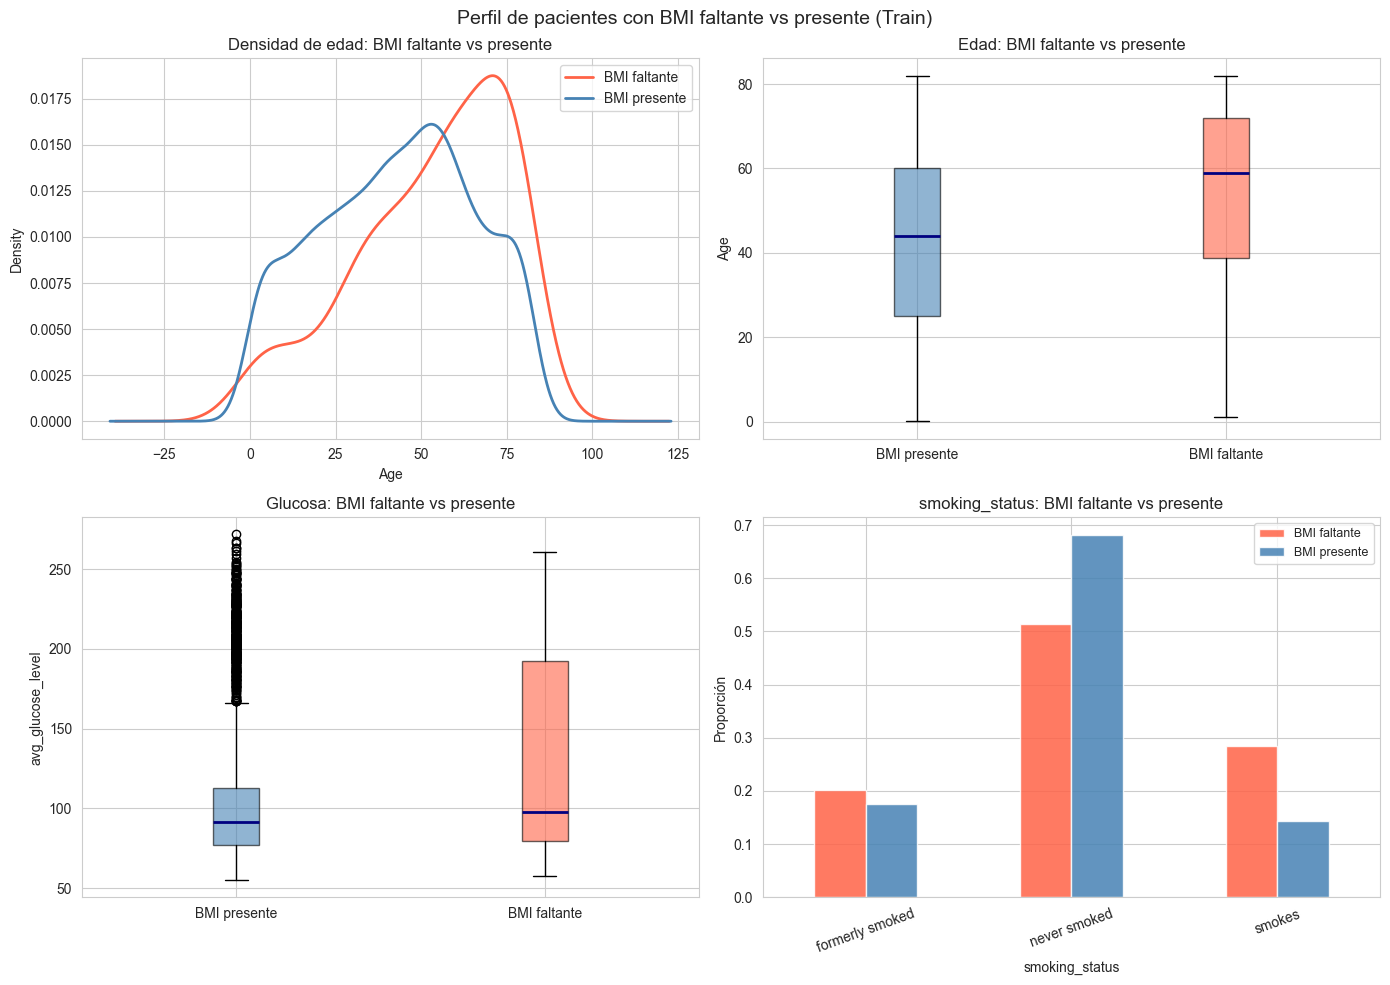

Edad media por grupo:
  BMI presente: 42.8 años
  BMI faltante: 53.3 años


In [386]:
# --- Perfil demográfico: BMI faltante vs presente ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bmi_missing_flag = X_train["bmi"].isnull()

# 1. Distribución de edad: KDE missing vs presente
X_train[bmi_missing_flag]["age"].plot(
    kind="kde", ax=axes[0, 0], label="BMI faltante", color="tomato", linewidth=2)
X_train[~bmi_missing_flag]["age"].plot(
    kind="kde", ax=axes[0, 0], label="BMI presente", color="steelblue", linewidth=2)
axes[0, 0].set_title("Densidad de edad: BMI faltante vs presente")
axes[0, 0].set_xlabel("Age")
axes[0, 0].legend()

# 2. Boxplot de edad por BMI missing
data_age = [X_train[~bmi_missing_flag]["age"], X_train[bmi_missing_flag]["age"]]
bp = axes[0, 1].boxplot(data_age, labels=["BMI presente", "BMI faltante"],
                        patch_artist=True, medianprops=dict(color="navy", linewidth=2))
bp["boxes"][0].set_facecolor("steelblue"); bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("tomato"); bp["boxes"][1].set_alpha(0.6)
axes[0, 1].set_title("Edad: BMI faltante vs presente")
axes[0, 1].set_ylabel("Age")

# 3. Glucosa por BMI missing
data_gluc = [X_train[~bmi_missing_flag]["avg_glucose_level"],
             X_train[bmi_missing_flag]["avg_glucose_level"]]
bp2 = axes[1, 0].boxplot(data_gluc, labels=["BMI presente", "BMI faltante"],
                         patch_artist=True, medianprops=dict(color="navy", linewidth=2))
bp2["boxes"][0].set_facecolor("steelblue"); bp2["boxes"][0].set_alpha(0.6)
bp2["boxes"][1].set_facecolor("tomato"); bp2["boxes"][1].set_alpha(0.6)
axes[1, 0].set_title("Glucosa: BMI faltante vs presente")
axes[1, 0].set_ylabel("avg_glucose_level")

# 4. Distribución de categóricas en BMI faltante
missing_cats = X_train[bmi_missing_flag]["smoking_status"].value_counts(normalize=True)
present_cats = X_train[~bmi_missing_flag]["smoking_status"].value_counts(normalize=True)
compare = pd.DataFrame({"BMI faltante": missing_cats, "BMI presente": present_cats})
compare.plot(kind="bar", ax=axes[1, 1], color=["tomato", "steelblue"],
             edgecolor="white", alpha=0.85)
axes[1, 1].set_title("smoking_status: BMI faltante vs presente")
axes[1, 1].set_ylabel("Proporción")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].legend(fontsize=9)

plt.suptitle("Perfil de pacientes con BMI faltante vs presente (Train)", fontsize=14)
plt.tight_layout()
plt.show()

print("Edad media por grupo:")
print(f"  BMI presente: {X_train[~bmi_missing_flag]["age"].mean():.1f} años")
print(f"  BMI faltante: {X_train[bmi_missing_flag]["age"].mean():.1f} años")

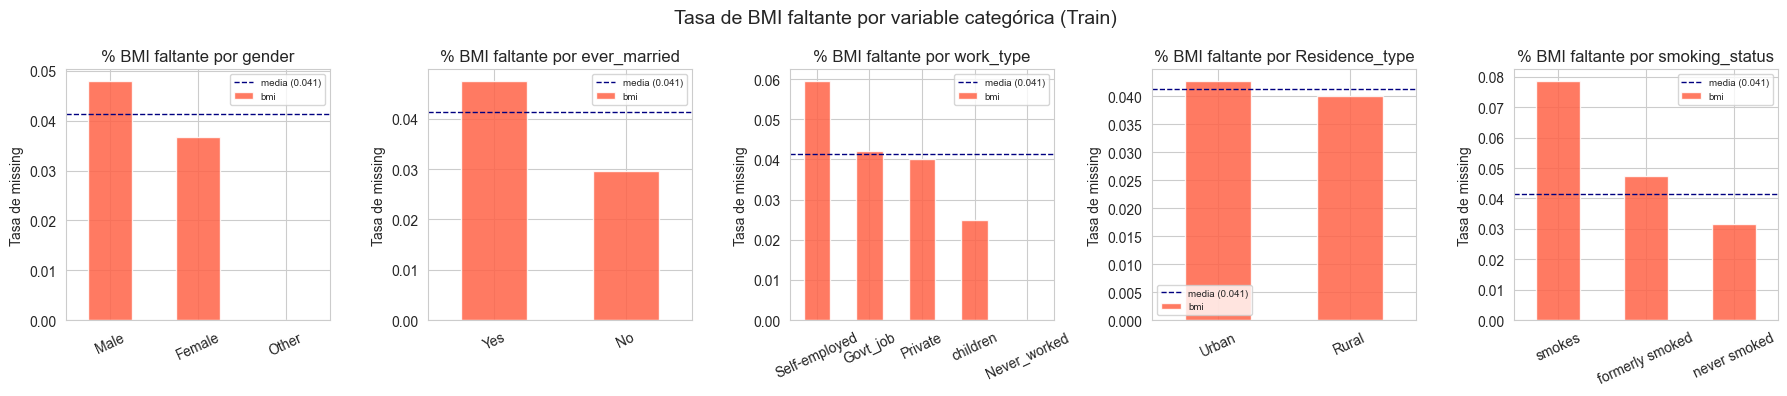

In [387]:
# --- Tasa de BMI faltante por variable categórica ---
bmi_missing_flag = X_train["bmi"].isnull().astype(int)
cat_check = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

fig, axes = plt.subplots(1, len(cat_check), figsize=(18, 4))

for i, col in enumerate(cat_check):
    rate = bmi_missing_flag.groupby(X_train[col]).mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=axes[i], color="tomato", edgecolor="white", alpha=0.85)
    axes[i].axhline(bmi_missing_flag.mean(), color="navy", linestyle="--",
                    linewidth=1, label=f"media ({bmi_missing_flag.mean():.3f})")
    axes[i].set_title(f"% BMI faltante por {col}")
    axes[i].set_ylabel("Tasa de missing")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].legend(fontsize=7)

plt.suptitle("Tasa de BMI faltante por variable categórica (Train)", fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_23268/2594108238.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_by_age = train_complete.groupby("age_group_temp")["bmi"].agg(["median", "mean", "count"])


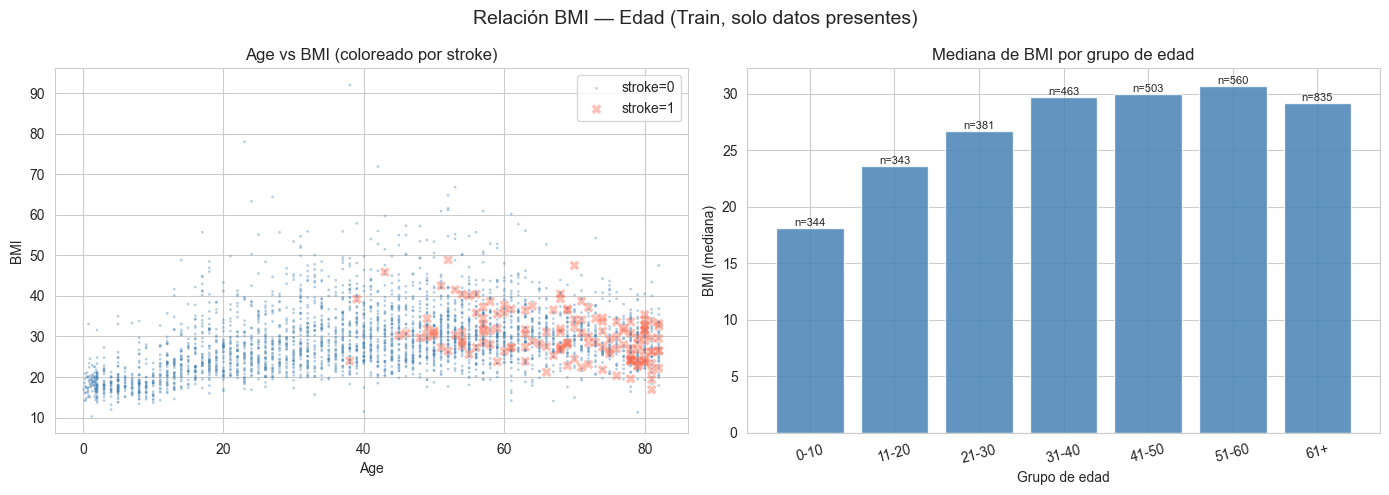

Mediana de BMI por grupo de edad:


,median,mean,count
age_group_temp,,,
0-10,18.15,18.77,344
11-20,23.60,25.25,343
21-30,26.70,28.26,381
31-40,29.70,31.25,463
41-50,30.00,31.47,503
51-60,30.70,32.12,560
61+,29.20,29.72,835


In [388]:
# --- Relación BMI vs Edad (solo datos presentes) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_complete = X_train[X_train["bmi"].notna()].copy()
y_complete = y_train[X_train["bmi"].notna()]

# 1. Scatter age vs BMI coloreado por stroke
for label, color, marker in zip([0, 1], ["steelblue", "tomato"], [".", "X"]):
    subset = train_complete[y_complete == label]
    axes[0].scatter(subset["age"], subset["bmi"],
                    c=color, label=f"stroke={label}", alpha=0.4,
                    s=15 if label == 0 else 50, marker=marker, edgecolors="none")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("BMI")
axes[0].set_title("Age vs BMI (coloreado por stroke)")
axes[0].legend()

# 2. Mediana de BMI por grupo de edad
age_bins = [0, 10, 20, 30, 40, 50, 60, np.inf]
age_labels = ["0-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61+"]
train_complete["age_group_temp"] = pd.cut(train_complete["age"], bins=age_bins,
                                          labels=age_labels, include_lowest=True)
bmi_by_age = train_complete.groupby("age_group_temp")["bmi"].agg(["median", "mean", "count"])

bars = axes[1].bar(bmi_by_age.index, bmi_by_age["median"],
                   color="steelblue", edgecolor="white", alpha=0.85)
for bar, count in zip(bars, bmi_by_age["count"]):
    axes[1].annotate(f"n={count}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=8)
axes[1].set_title("Mediana de BMI por grupo de edad")
axes[1].set_ylabel("BMI (mediana)")
axes[1].set_xlabel("Grupo de edad")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Relación BMI — Edad (Train, solo datos presentes)", fontsize=14)
plt.tight_layout()
plt.show()

print("Mediana de BMI por grupo de edad:")
display(bmi_by_age.round(2))

In [389]:
# --- Resumen: BMI faltante vs presente ---
bmi_missing_flag = X_train["bmi"].isnull()
missing = X_train[bmi_missing_flag]
present = X_train[~bmi_missing_flag]
y_missing = y_train[bmi_missing_flag]
y_present = y_train[~bmi_missing_flag]

resumen = pd.DataFrame({
    "BMI faltante": [
        len(missing),
        missing["age"].mean(),
        missing["age"].median(),
        missing["avg_glucose_level"].mean(),
        (missing["ever_married"] == "No").mean(),
        y_missing.mean(),
    ],
    "BMI presente": [
        len(present),
        present["age"].mean(),
        present["age"].median(),
        present["avg_glucose_level"].mean(),
        (present["ever_married"] == "No").mean(),
        y_present.mean(),
    ]
}, index=["N", "Edad media", "Edad mediana", "Glucosa media",
          "% ever_married=No", "Tasa de stroke"])

display(resumen.round(4))


,BMI faltante,BMI presente
N,148.0000,3429.0000
Edad media,53.3076,42.8164
Edad mediana,59.0000,44.0000
Glucosa media,125.3346,105.1211
% ever_married=No,0.2432,0.3441
Tasa de stroke,0.2095,0.0417



  1. BMI faltante no parece estar fuertemente asociado al target (stroke)
  2. La distribución de edad entre missing y presente es similar
  3. BMI varía significativamente con la edad (niños tienen BMI mucho menor). Justifica imputar con la mediana por grupo de edad, no la mediana global
  4. El mecanismo de missing parece ser MAR (asociado a otras variables) o MCAR

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_23268/2136968489.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_stats = train_bmi.groupby("age_fine")["bmi"].agg(


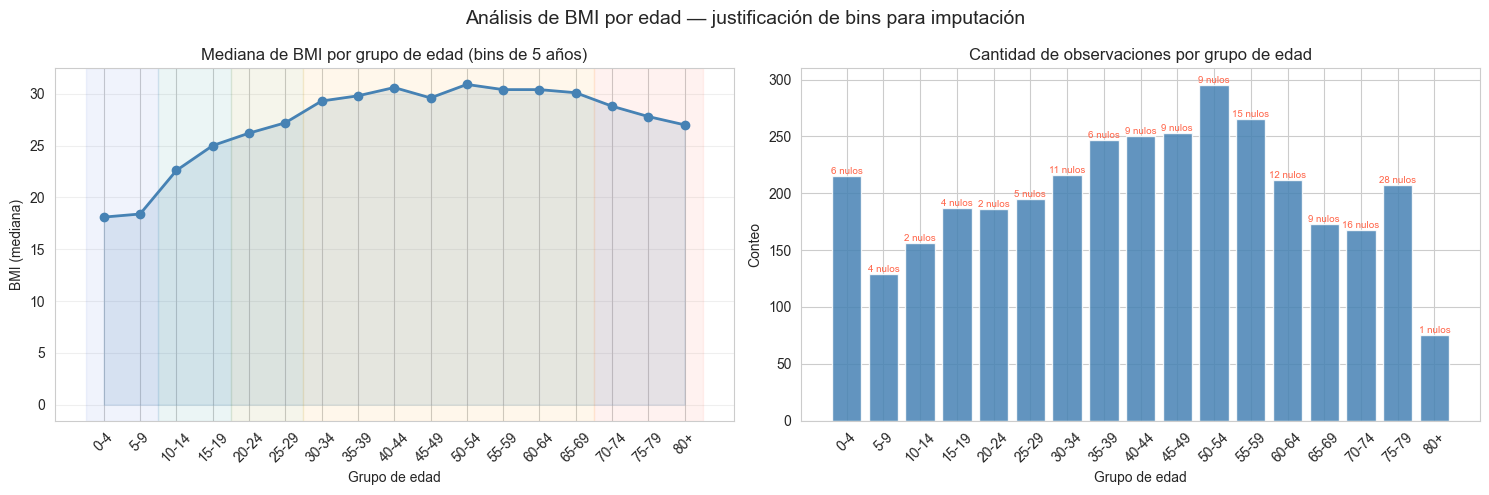

,mediana,media,conteo,nulos
age_fine,,,,
0-4,18.1,18.7,215,6
5-9,18.4,19.0,129,4
10-14,22.6,23.2,156,2
15-19,25.0,27.0,187,4
20-24,26.2,28.0,186,2
25-29,27.2,28.5,195,5
30-34,29.3,31.2,216,11
35-39,29.8,31.3,247,6
40-44,30.6,31.7,250,9



Observaciones:
  - 0-10 años: BMI bajo (~18), grupo claramente diferenciado
  - 10-20 años: salto importante (BMI 23→25), transición pubertad
  - 20-30 años: BMI intermedio (~27), aún en crecimiento
  - 30-70 años: meseta estable (BMI ~29-31), no justifica dividir en 4 bins
  - 70+ años: leve descenso (BMI ~28), mayor tasa de nulos

→ Bins propuestos para imputación: [0-10, 10-20, 20-30, 30-70, 70+]


In [390]:
# --- Justificación de bins de edad para imputación de BMI ---
# Analizamos la mediana de BMI con bins granulares de 5 años para
# identificar dónde hay saltos reales vs mesetas estables.

fine_bins = list(range(0, 85, 5)) + [np.inf]
fine_labels = [f"{b}-{fine_bins[i+1]-1}" if fine_bins[i+1] != np.inf else f"{b}+"
               for i, b in enumerate(fine_bins[:-1])]

train_bmi = X_train.copy()
train_bmi["age_fine"] = pd.cut(train_bmi["age"], bins=fine_bins,
                               labels=fine_labels, include_lowest=True)

bmi_stats = train_bmi.groupby("age_fine")["bmi"].agg(
    mediana="median", media="mean", conteo="count",
    nulos=lambda x: x.isnull().sum()
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Mediana de BMI por bin de 5 años
axes[0].plot(bmi_stats.index.astype(str), bmi_stats["mediana"],
             marker="o", color="steelblue", linewidth=2, markersize=6)
axes[0].fill_between(range(len(bmi_stats)), bmi_stats["mediana"],
                     alpha=0.15, color="steelblue")
axes[0].set_title("Mediana de BMI por grupo de edad (bins de 5 años)")
axes[0].set_ylabel("BMI (mediana)")
axes[0].set_xlabel("Grupo de edad")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

# Marcar las zonas propuestas
for xmin, xmax, label, color in [(0, 2, "0-10", "royalblue"),
                                  (2, 4, "10-20", "teal"),
                                  (4, 6, "20-30", "olive"),
                                  (6, 14, "30-70", "orange"),
                                  (14, len(bmi_stats), "70+", "tomato")]:
    axes[0].axvspan(xmin - 0.5, min(xmax - 0.5, len(bmi_stats) - 0.5),
                    alpha=0.08, color=color)

# 2. Conteo por bin
bars = axes[1].bar(bmi_stats.index.astype(str), bmi_stats["conteo"],
                   color="steelblue", edgecolor="white", alpha=0.85)
axes[1].set_title("Cantidad de observaciones por grupo de edad")
axes[1].set_ylabel("Conteo")
axes[1].set_xlabel("Grupo de edad")
axes[1].tick_params(axis="x", rotation=45)
for bar, nulos in zip(bars, bmi_stats["nulos"]):
    if nulos > 0:
        axes[1].annotate(f"{int(nulos)} nulos",
                         (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                         ha="center", va="bottom", fontsize=7, color="tomato")

plt.suptitle("Análisis de BMI por edad — justificación de bins para imputación", fontsize=14)
plt.tight_layout()
plt.show()

display(bmi_stats)

print("\nObservaciones:")
print("  - 0-10 años: BMI bajo (~18), grupo claramente diferenciado")
print("  - 10-20 años: salto importante (BMI 23→25), transición pubertad")
print("  - 20-30 años: BMI intermedio (~27), aún en crecimiento")
print("  - 30-70 años: meseta estable (BMI ~29-31), no justifica dividir en 4 bins")
print("  - 70+ años: leve descenso (BMI ~28), mayor tasa de nulos")
print("\n→ Bins propuestos para imputación: [0-10, 10-20, 20-30, 30-70, 70+]")

## 5. Analysis of missing values in `bmi`

### Preprocessing decision for `bmi`

The original notebook keeps a missing-value flag and imputes `bmi` using the median, fitted on the training set only.


In [401]:
# Imputación de BMI usando la mediana por rango de edad
def impute_bmi_by_age_group(df, age_col="age", bmi_col="bmi"):
    age_bins = [0, 10, 20, 30, 70, np.inf]
    age_labels = ['0-10', '11-20', '21-30', '31-70', '71+']
    df = df.copy()
    df['age_group_bmi_imp'] = pd.cut(df[age_col], bins=age_bins, labels=age_labels, include_lowest=True)
    # Calcular la mediana de BMI por grupo de edad
    medians = df.groupby('age_group_bmi_imp')[bmi_col].transform('median')
    # Imputar valores faltantes
    df[bmi_col] = df[bmi_col].fillna(medians)
    return df

# Aplicar imputación en X_train y X_val
X_train = impute_bmi_by_age_group(X_train)
X_val = impute_bmi_by_age_group(X_val)

# Verificar imputación
display(X_train[["age", "age_group_bmi_imp", "bmi"]].head(10))
print("Valores faltantes en BMI tras imputación por grupo de edad:", X_train["bmi"].isnull().sum())

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_23268/1057347017.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = df.groupby('age_group_bmi_imp')[bmi_col].transform('median')
/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_23268/1057347017.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = df.groupby('age_group_bmi_imp')[bmi_col].transform('median')


,age,age_group_bmi_imp,bmi
2226,52.0,31-70,22.0
3927,62.0,31-70,36.3
3358,81.0,71+,29.4
4152,55.0,31-70,28.0
4866,37.0,31-70,36.1
2779,6.0,0-10,19.8
1299,51.0,31-70,35.3
853,40.0,31-70,36.6
5020,5.0,0-10,17.6
3363,61.0,31-70,43.4


Valores faltantes en BMI tras imputación por grupo de edad: 0


## 6. Encoding and construction of the processed matrices

In [402]:
# Gender encoding
X_train["gender"] = X_train["gender"].map({
    "Male": 0,
    "Female": 1
})

X_val["gender"] = X_val["gender"].map({
    "Male": 0,
    "Female": 1
})

# Ever married encoding
X_train["ever_married"] = X_train["ever_married"].map({
    "Yes": 1,
    "No": 0
})

X_val["ever_married"] = X_val["ever_married"].map({
    "Yes": 1,
    "No": 0
})

# Residence type encoding
X_train["Residence_type"] = X_train["Residence_type"].map({
    "Urban": 1,
    "Rural": 0
})

X_val["Residence_type"] = X_val["Residence_type"].map({
    "Urban": 1,
    "Rural": 0
})

In [403]:
# Unificar categorías de work_type: reemplazar 'children' por 'Never_worked'
X_train.loc[X_train["work_type"] == "children", "work_type"] = "Never_worked"
X_val.loc[X_val["work_type"] == "children", "work_type"] = "Never_worked"

print(X_train["work_type"].unique())

['Govt_job' 'Private' 'Self-employed' 'Never_worked']


In [404]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = [
    "work_type",
    "smoking_status",
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=int, drop='first')

# Fit only on train
X_train_encoded = encoder.fit_transform(X_train[cat_cols])

# Transform validation
X_val_encoded = encoder.transform(X_val[cat_cols])

In [405]:
encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=encoded_cols,
    index=X_val.index
)

display(X_train_encoded.head())

,work_type_Never_worked,work_type_Private,work_type_Self-employed,smoking_status_never smoked,smoking_status_smokes
2226,0,0,0,0,0
3927,0,1,0,1,0
3358,0,0,1,1,0
4152,0,0,1,0,1
4866,0,1,0,0,1


In [406]:
num_cols_model = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]

X_train_final = pd.concat(
    [X_train[num_cols_model + ["gender"]], X_train_encoded],
    axis=1
)

X_val_final = pd.concat(
    [X_val[num_cols_model + ["gender"]], X_val_encoded],
    axis=1
)

print("X_train_final shape:", X_train_final.shape)
print("X_val_final shape:", X_val_final.shape)
display(X_train_final.head())

X_train_final shape: (3577, 11)
X_val_final shape: (1533, 11)


,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,work_type_Never_worked,work_type_Private,work_type_Self-employed,smoking_status_never smoked,smoking_status_smokes
2226,52.0,107.84,22.0,0,0,1.0,0,0,0,0,0
3927,62.0,88.32,36.3,0,0,1.0,0,1,0,1,0
3358,81.0,95.49,29.4,0,1,0.0,0,0,1,1,0
4152,55.0,73.57,28.0,0,0,0.0,0,0,1,0,1
4866,37.0,103.66,36.1,0,0,1.0,0,1,0,0,1


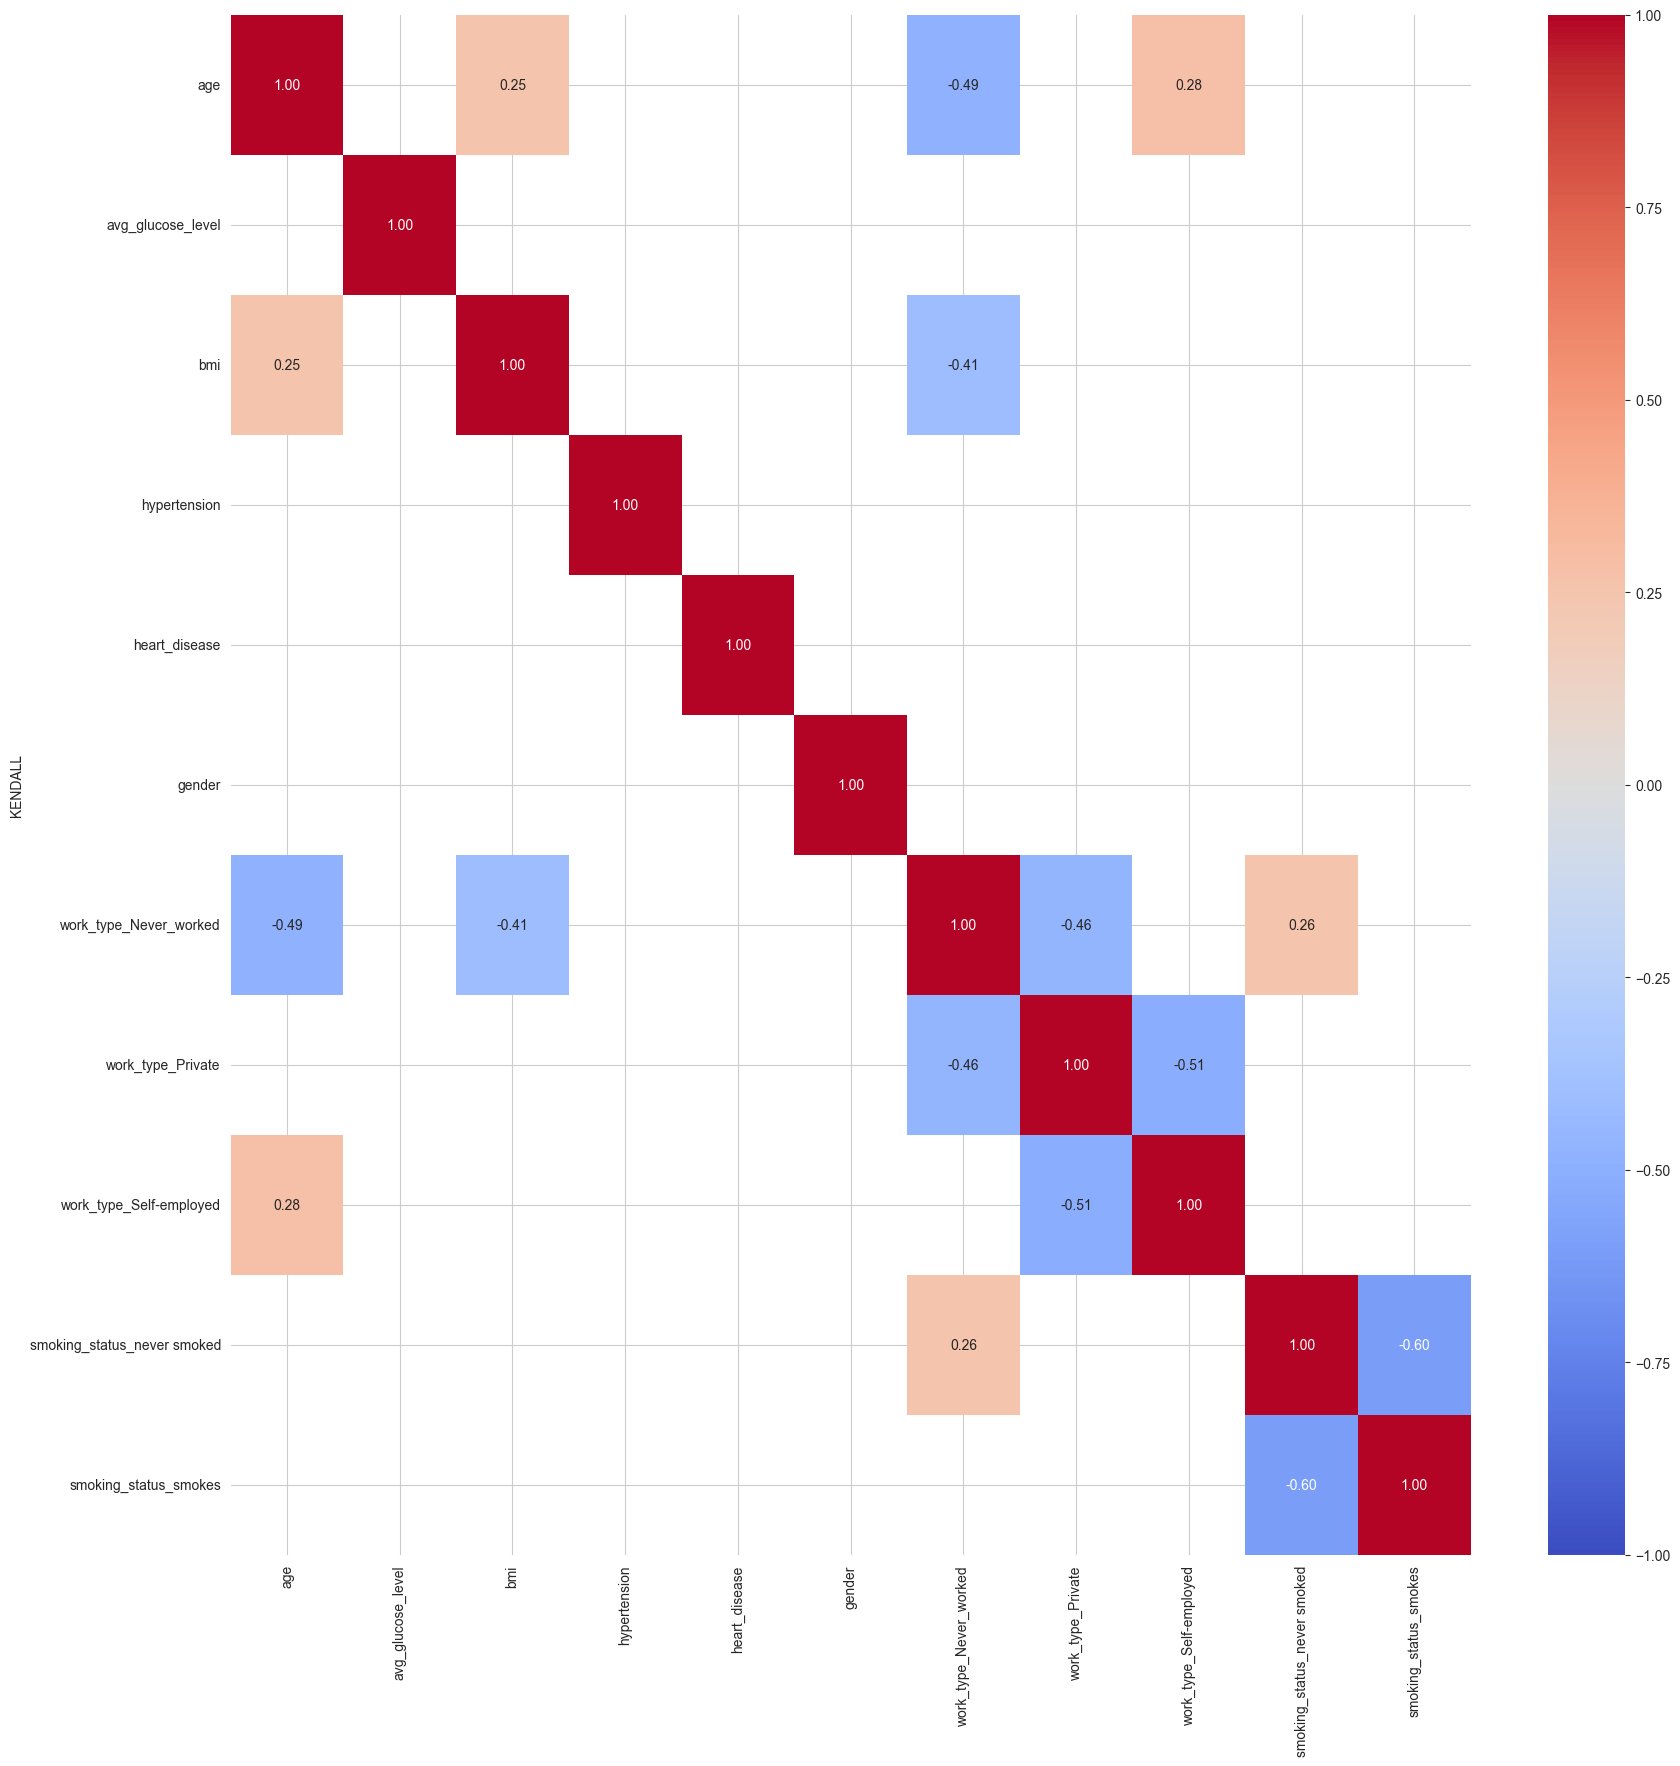

In [407]:
umbral = 0.25
mask_for_heatmap = (X_train_final.corr(method='kendall').abs() < umbral)
plt.figure(figsize=(20,20))
sns.heatmap(
    X_train_final.corr(method='kendall'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,
    mask=mask_for_heatmap)
plt.ylabel('KENDALL')
plt.show()

In [408]:
print("Missing values in processed matrices:")
print("Train:", X_train_final.isnull().sum().sum())
print("Validation:", X_val_final.isnull().sum().sum())

Missing values in processed matrices:
Train: 1
Validation: 0


## 7. Correlation and association analysis

This section preserves and reorganizes the notebook's different approaches to analyzing feature–target association:
- classical correlation among numerical variables,
- correlation against the target after encoding,
- point-biserial correlation for numerical variables,
- non-linear / non-parametric association using Spearman and mutual information,
- association for categorical variables using Chi-square and Cramér's V.


In [409]:
# Analysis dataframe on the training set
train_df = X_train.copy()
train_df["stroke"] = y_train.values

num_cols = ["age", "avg_glucose_level", "bmi"]
bin_cols = ["hypertension", "heart_disease"]
cat_cols_analysis = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

print("Train analysis shape:", train_df.shape)

Train analysis shape: (3577, 13)


### 7.1 Correlation among numerical variables

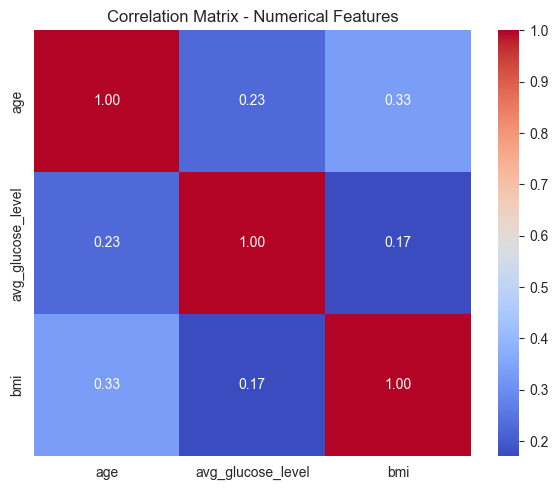

,age,avg_glucose_level,bmi
age,1.000000,0.227899,0.333031
avg_glucose_level,0.227899,1.000000,0.170527
bmi,0.333031,0.170527,1.000000


In [410]:
corr_matrix = train_df[num_cols].corr(method="pearson")

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Numerical Features")
plt.tight_layout()
plt.show()

display(corr_matrix)

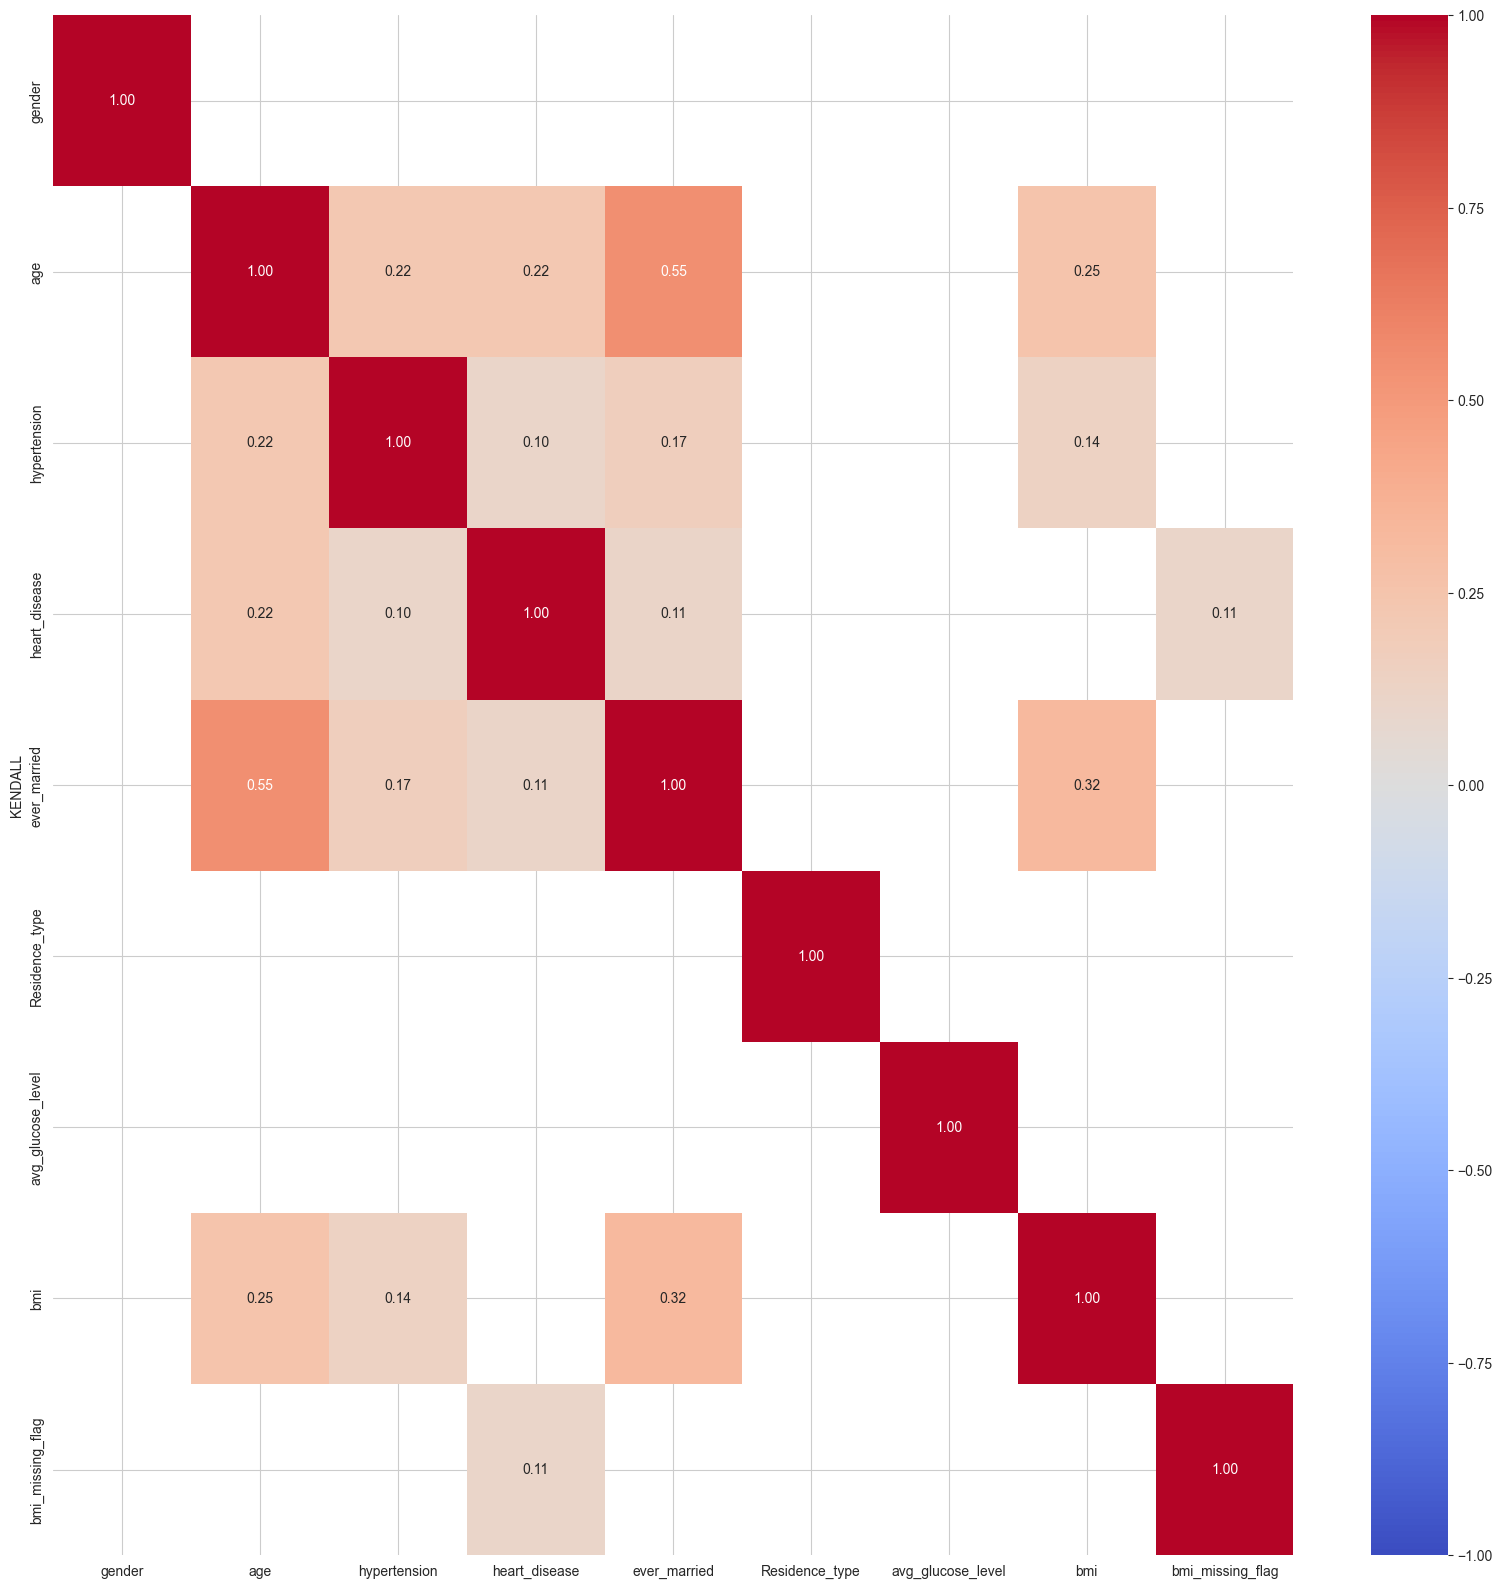

In [411]:
# Heatmap de correlación de Kendall con umbral y solo columnas numéricas
umbral = 0.1  # Puedes ajustar este valor

# Seleccionar solo columnas numéricas y eliminar filas con NaN
X_train_corr = X_train.select_dtypes(include=[float, int]).dropna()

mask_for_heatmap = (X_train_corr.corr(method='kendall').abs() < umbral)
plt.figure(figsize=(20, 20))
sns.heatmap(
    X_train_corr.corr(method='kendall'),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    mask=mask_for_heatmap
)
plt.ylabel('KENDALL')
plt.show()

### 7.2 Correlation with the target after encoding

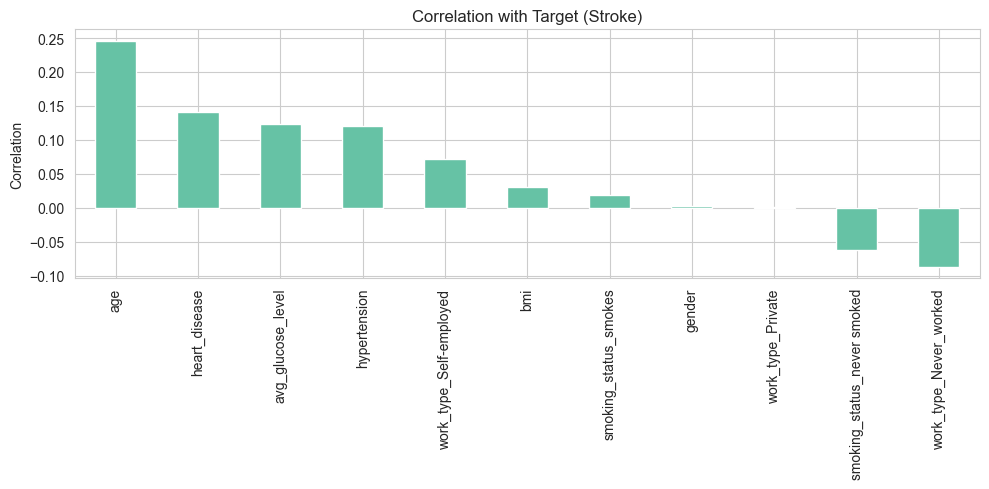

stroke                         1.000000
age                            0.246029
heart_disease                  0.141567
avg_glucose_level              0.123389
hypertension                   0.120188
work_type_Self-employed        0.071302
bmi                            0.030358
smoking_status_smokes          0.018129
gender                         0.003059
work_type_Private              0.001501
smoking_status_never smoked   -0.061773
work_type_Never_worked        -0.086639
Name: stroke, dtype: float64

In [412]:
df_corr = X_train_final.copy()
df_corr["stroke"] = y_train

corr_with_target = df_corr.corr()["stroke"].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_with_target.drop("stroke").plot(kind="bar")
plt.title("Correlation with Target (Stroke)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

display(corr_with_target)

### 7.3 Pairwise visualization for selected numerical variables

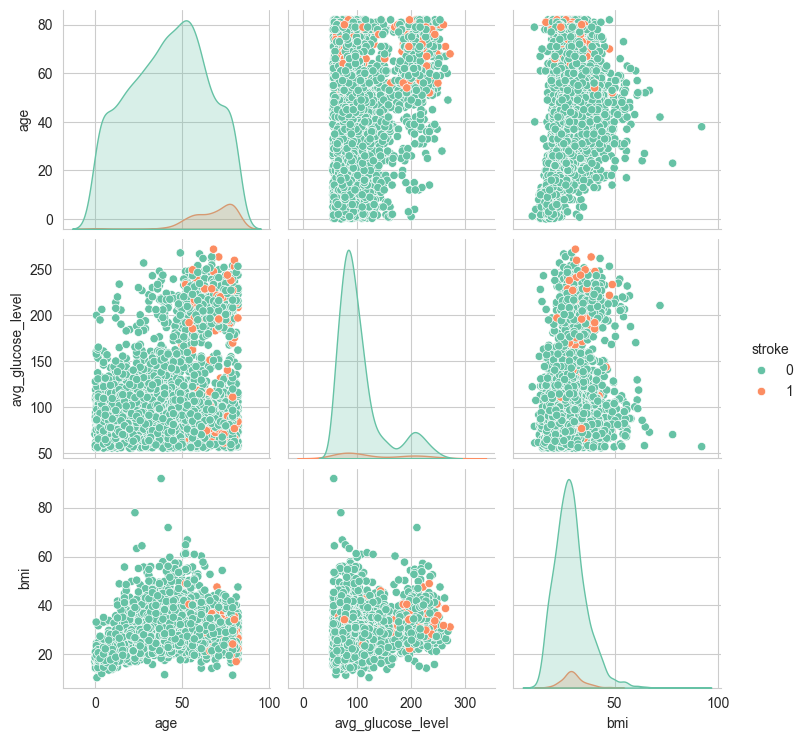

In [413]:
sns.pairplot(
    train_df[["age", "avg_glucose_level", "bmi", "stroke"]],
    hue="stroke",
    diag_kind="kde"
)
plt.show()

### 7.4 Distribution by class

The following two cells are intentionally kept, because both were present in the original notebook.


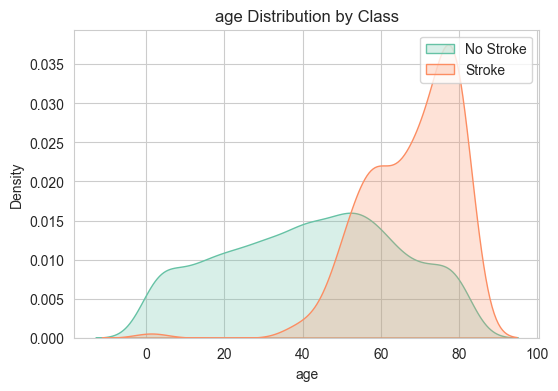

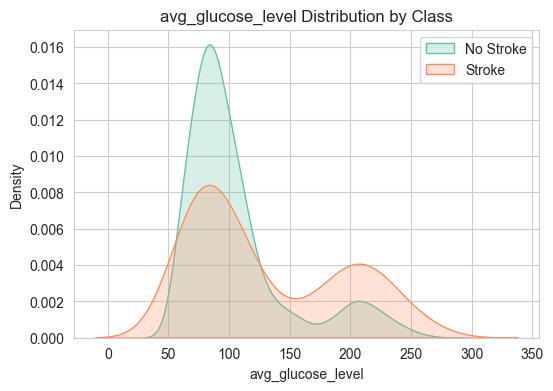

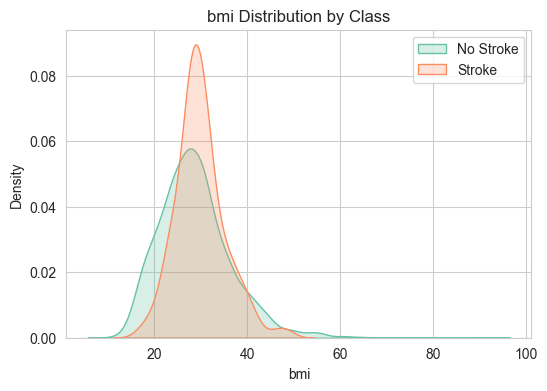

In [414]:
for col in ["age", "avg_glucose_level", "bmi"]:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(X_train[col][y_train == 0], label="No Stroke", fill=True)
    sns.kdeplot(X_train[col][y_train == 1], label="Stroke", fill=True)
    plt.title(f"{col} Distribution by Class")
    plt.legend()
    plt.show()

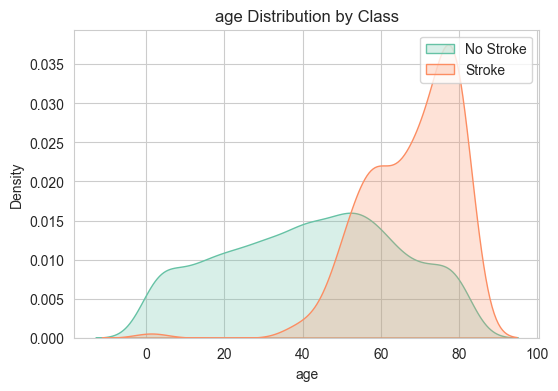

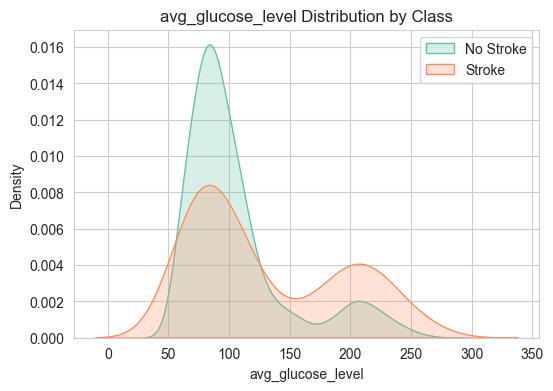

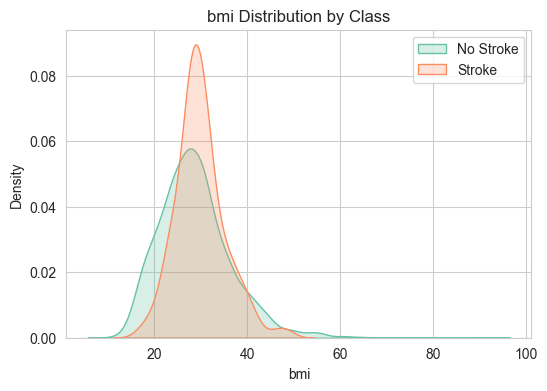

In [415]:
# Repeated class-distribution visualization retained from the original notebook
for col in ["age", "avg_glucose_level", "bmi"]:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(X_train[col][y_train == 0], label="No Stroke", fill=True)
    sns.kdeplot(X_train[col][y_train == 1], label="Stroke", fill=True)
    plt.title(f"{col} Distribution by Class")
    plt.legend()
    plt.show()

### 7.5 Numerical variables vs target — point-biserial correlation

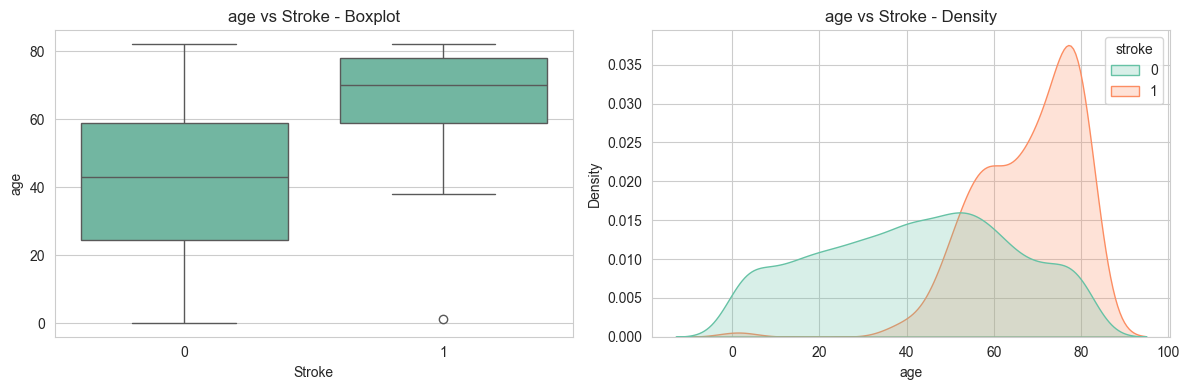

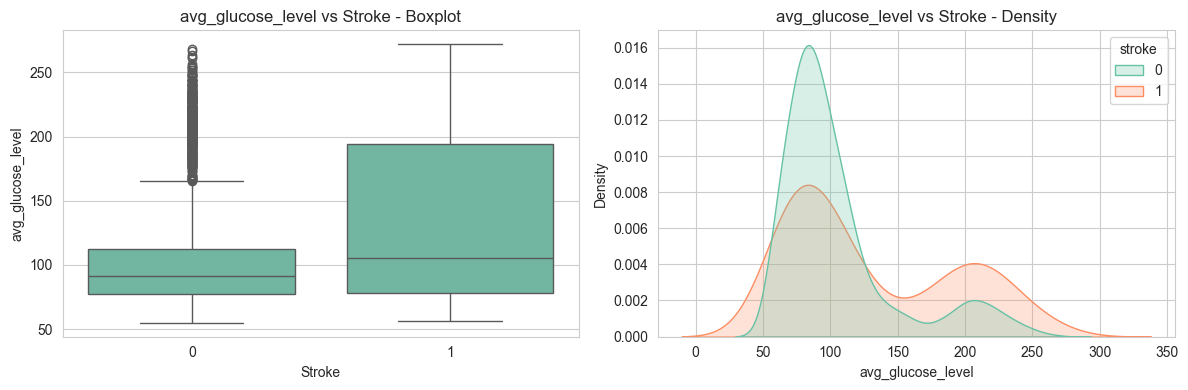

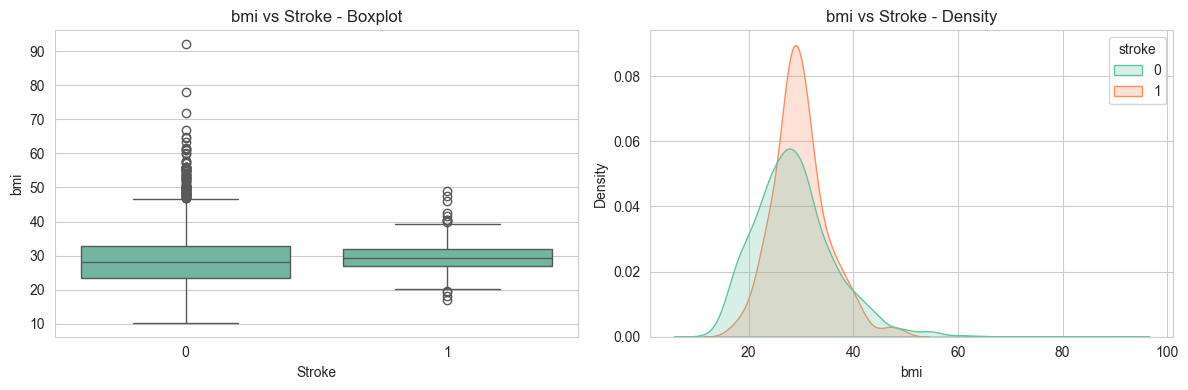

,feature,point_biserial_corr,p_value
0,age,0.246029,1.821863e-50
1,avg_glucose_level,0.123389,1.307750e-13
2,bmi,0.030358,6.945778e-02


In [416]:
from scipy.stats import pointbiserialr, chi2_contingency

num_target_results = []

for col in num_cols:
    r, p = pointbiserialr(train_df["stroke"], train_df[col])
    num_target_results.append({
        "feature": col,
        "point_biserial_corr": r,
        "p_value": p
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(data=train_df, x="stroke", y=col, ax=axes[0])
    axes[0].set_title(f"{col} vs Stroke - Boxplot")
    axes[0].set_xlabel("Stroke")
    axes[0].set_ylabel(col)

    sns.kdeplot(data=train_df, x=col, hue="stroke", fill=True, common_norm=False, ax=axes[1])
    axes[1].set_title(f"{col} vs Stroke - Density")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

num_target_df = pd.DataFrame(num_target_results).sort_values(
    by="point_biserial_corr", key=lambda s: s.abs(), ascending=False
)

display(num_target_df)

### 7.6 Binary variables vs target

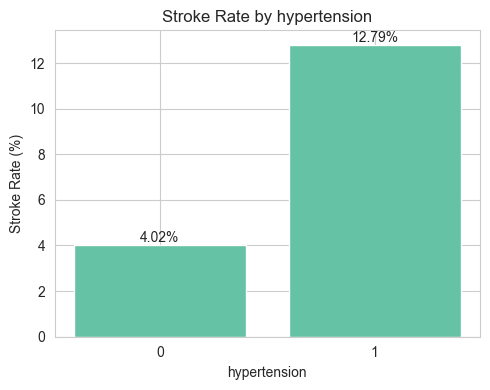


Contingency table: hypertension vs stroke


stroke,0,1
hypertension,,
0,0.959790,0.040210
1,0.872093,0.127907


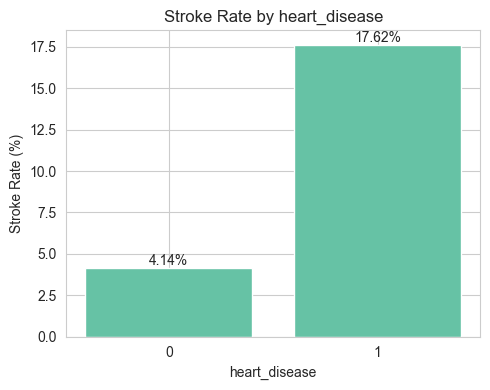


Contingency table: heart_disease vs stroke


stroke,0,1
heart_disease,,
0,0.958629,0.041371
1,0.823834,0.176166


,hypertension,mean,count,sum,stroke_rate_pct,feature,heart_disease
0,0.0,0.040210,3233,130,4.021033,hypertension,NaN
1,1.0,0.127907,344,44,12.790698,hypertension,NaN
0,NaN,0.041371,3384,140,4.137116,heart_disease,0.0
1,NaN,0.176166,193,34,17.616580,heart_disease,1.0


In [417]:
bin_target_results = []

for col in bin_cols:
    summary = train_df.groupby(col)["stroke"].agg(["mean", "count", "sum"]).reset_index()
    summary["stroke_rate_pct"] = summary["mean"] * 100
    bin_target_results.append(summary.assign(feature=col))

    plt.figure(figsize=(5, 4))
    bars = plt.bar(summary[col].astype(str), summary["stroke_rate_pct"])
    plt.title(f"Stroke Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Stroke Rate (%)")

    for bar, val in zip(bars, summary["stroke_rate_pct"]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

    print(f"\nContingency table: {col} vs stroke")
    display(pd.crosstab(train_df[col], train_df["stroke"], normalize="index"))

bin_target_df = pd.concat(bin_target_results, axis=0)
display(bin_target_df)

### 7.7 Categorical variables vs target — Chi-square and Cramér's V

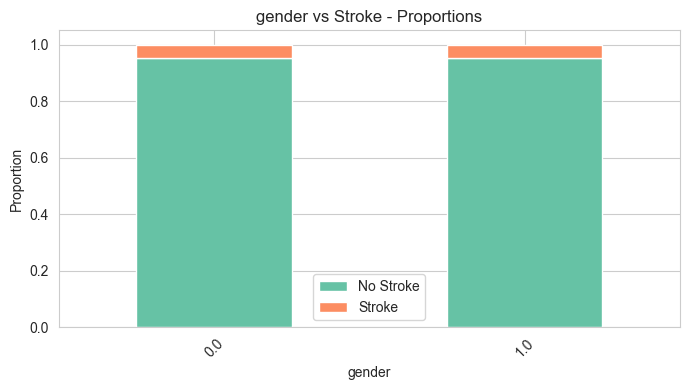

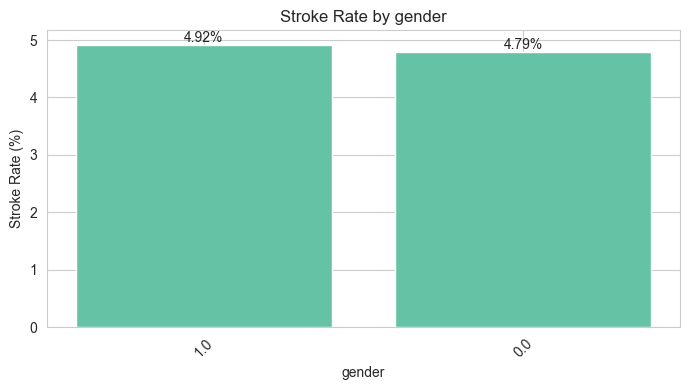

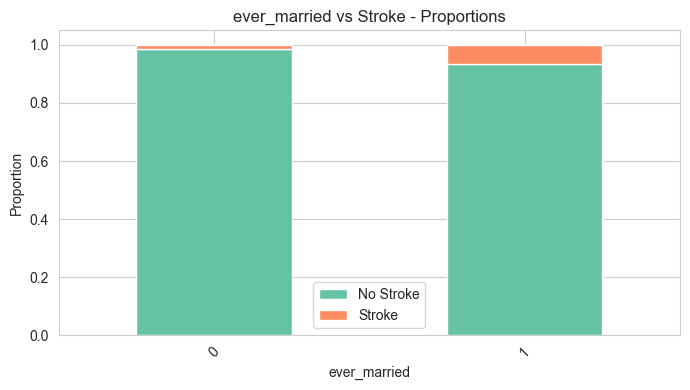

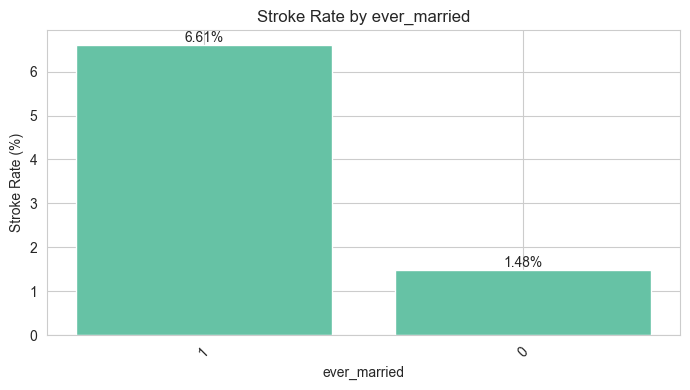

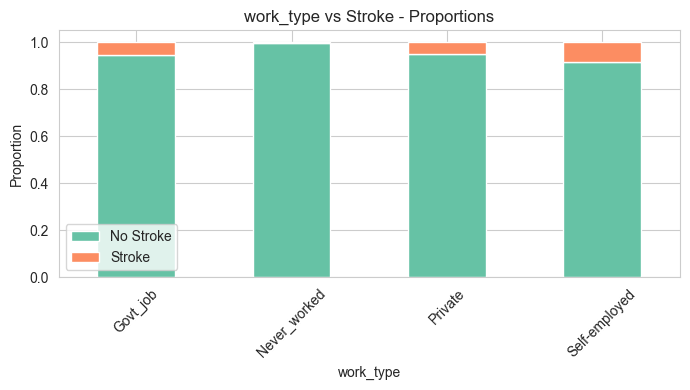

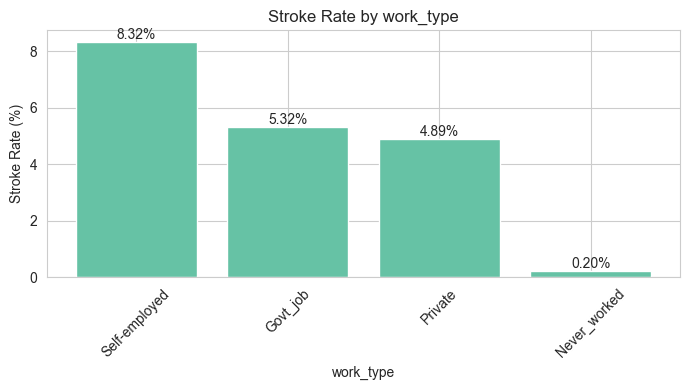

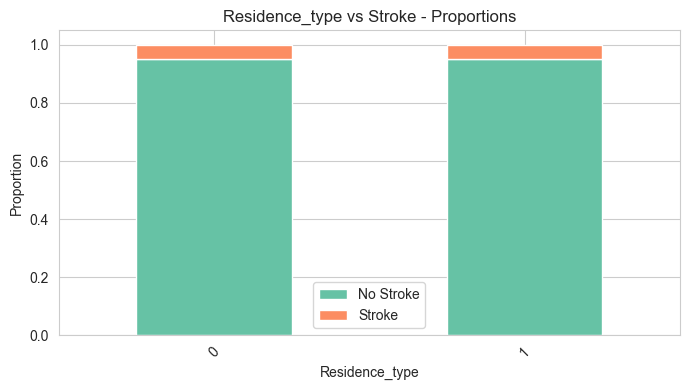

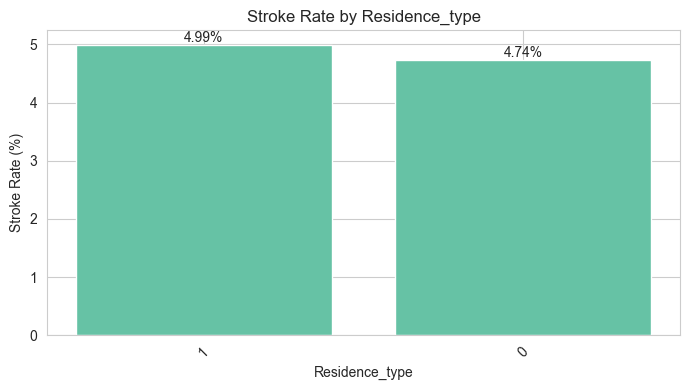

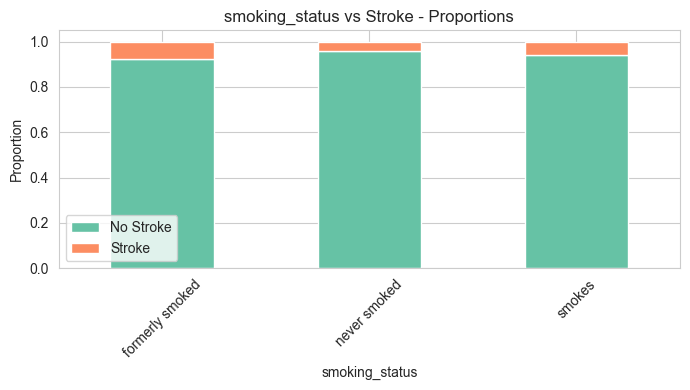

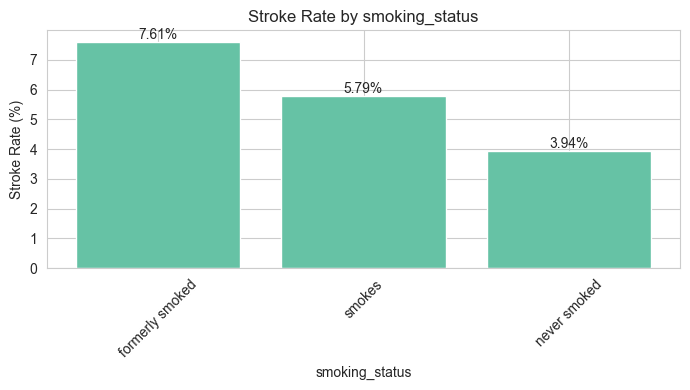

,feature,chi2_p_value,cramers_v
1,ever_married,2.556419e-11,0.110280
2,work_type,2.164576e-08,0.057578
4,smoking_status,3.887835e-04,0.043780
0,gender,9.171480e-01,0.000000
3,Residence_type,7.802566e-01,0.000000


In [418]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / max((kcorr - 1), (rcorr - 1)))

cat_target_results = []

for col in cat_cols_analysis:
    contingency = pd.crosstab(train_df[col], train_df["stroke"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    cv = cramers_v(train_df[col], train_df["stroke"])

    cat_target_results.append({
        "feature": col,
        "chi2_p_value": p,
        "cramers_v": cv
    })

    prop_table = pd.crosstab(train_df[col], train_df["stroke"], normalize="index")
    prop_table.plot(kind="bar", stacked=True, figsize=(7, 4))
    plt.title(f"{col} vs Stroke - Proportions")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend(["No Stroke", "Stroke"])
    plt.tight_layout()
    plt.show()

    rate = train_df.groupby(col)["stroke"].mean().sort_values(ascending=False) * 100
    plt.figure(figsize=(7, 4))
    bars = plt.bar(rate.index.astype(str), rate.values)
    plt.title(f"Stroke Rate by {col}")
    plt.ylabel("Stroke Rate (%)")
    plt.xlabel(col)
    plt.xticks(rotation=45)

    for bar, val in zip(bars, rate.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

cat_target_df = pd.DataFrame(cat_target_results).sort_values(
    by="cramers_v", ascending=False
)

display(cat_target_df)

### 7.8 Association matrix among categorical variables

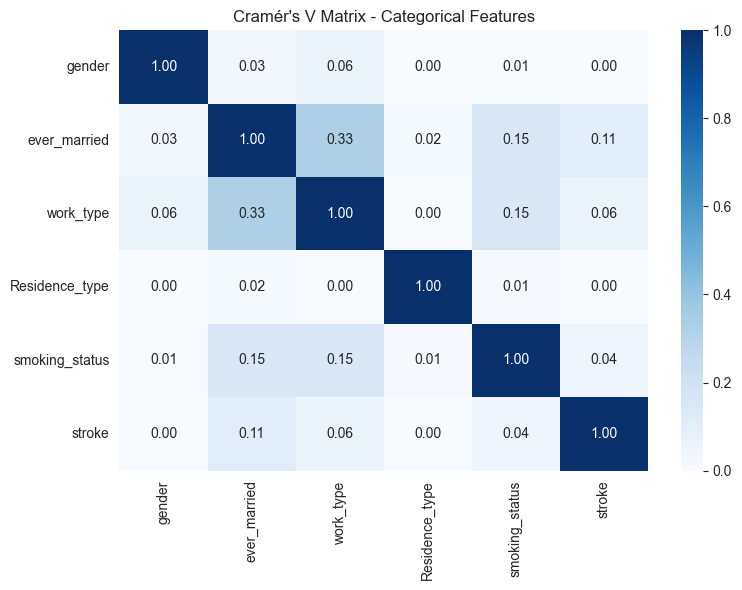

,gender,ever_married,work_type,Residence_type,smoking_status,stroke
gender,0.999424,0.034019,0.059488,0.000000,0.006497,0.000000
ever_married,0.034019,0.999377,0.328295,0.018982,0.154295,0.110280
work_type,0.059488,0.328295,1.000000,0.000000,0.154070,0.057578
Residence_type,0.000000,0.018982,0.000000,0.999441,0.013761,0.000000
smoking_status,0.006497,0.154295,0.154070,0.013761,1.000000,0.043780
stroke,0.000000,0.110280,0.057578,0.000000,0.043780,0.996979


In [419]:
cat_all = cat_cols_analysis + ["stroke"]

cramers_matrix = pd.DataFrame(index=cat_all, columns=cat_all, dtype=float)

for col1 in cat_all:
    for col2 in cat_all:
        cramers_matrix.loc[col1, col2] = cramers_v(train_df[col1], train_df[col2])

plt.figure(figsize=(8, 6))
sns.heatmap(cramers_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Cramér's V Matrix - Categorical Features")
plt.tight_layout()
plt.show()

display(cramers_matrix)

### 7.9 Numerical variables vs target — direct point-biserial table retained from the original workflow

In [420]:
results = []

for col in num_cols:
    r, p = pointbiserialr(y_train, X_train[col])

    results.append({
        "feature": col,
        "correlation": r,
        "abs_correlation": abs(r),
        "p_value": p
    })

corr_df = pd.DataFrame(results).sort_values(by="abs_correlation", ascending=False)

display(corr_df)

,feature,correlation,abs_correlation,p_value
0,age,0.246029,0.246029,1.821863e-50
1,avg_glucose_level,0.123389,0.123389,1.307750e-13
2,bmi,0.030358,0.030358,6.945778e-02


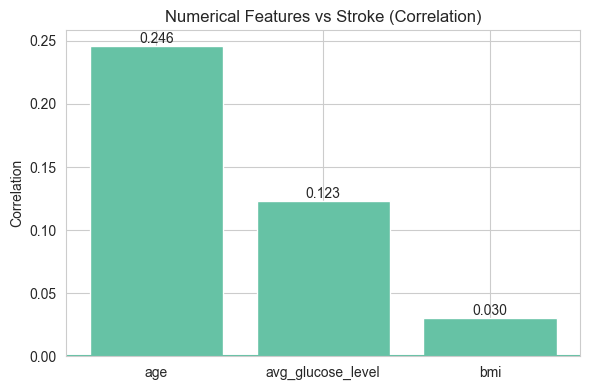

In [421]:
plt.figure(figsize=(6, 4))

bars = plt.bar(corr_df["feature"], corr_df["correlation"])

plt.title("Numerical Features vs Stroke (Correlation)")
plt.ylabel("Correlation")
plt.axhline(0)

for bar, val in zip(bars, corr_df["correlation"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 7.10 Non-linear / non-parametric association: Spearman correlation

In [422]:
results_spearman = []

for col in ["age", "avg_glucose_level", "bmi"]:
    corr = pd.Series(X_train[col]).corr(y_train, method="spearman")

    results_spearman.append({
        "feature": col,
        "spearman_corr": corr,
        "abs_corr": abs(corr)
    })

spearman_df = pd.DataFrame(results_spearman).sort_values(
    by="abs_corr", ascending=False
)

display(spearman_df)

,feature,spearman_corr,abs_corr
0,age,0.251601,0.251601
1,avg_glucose_level,0.070342,0.070342
2,bmi,0.052951,0.052951


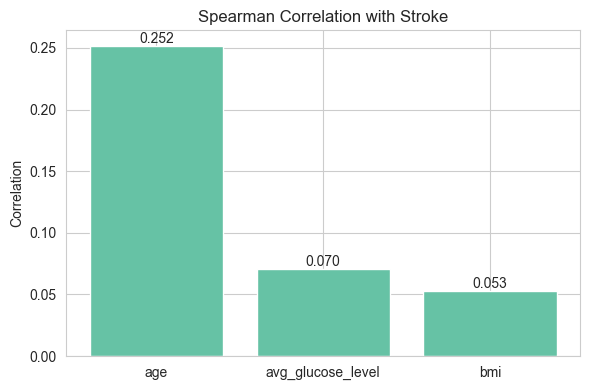

In [423]:
plt.figure(figsize=(6, 4))

bars = plt.bar(spearman_df["feature"], spearman_df["spearman_corr"])

plt.title("Spearman Correlation with Stroke")
plt.ylabel("Correlation")

for bar, val in zip(bars, spearman_df["spearman_corr"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 7.11 Non-linear association: mutual information

In [424]:
from sklearn.feature_selection import mutual_info_classif

X_num = X_train[["age", "avg_glucose_level", "bmi"]]

mi = mutual_info_classif(X_num, y_train, random_state=42)

mi_df = pd.DataFrame({
    "feature": X_num.columns,
    "mutual_info": mi
}).sort_values(by="mutual_info", ascending=False)

display(mi_df)

,feature,mutual_info
0,age,0.041748
2,bmi,0.014225
1,avg_glucose_level,0.005168


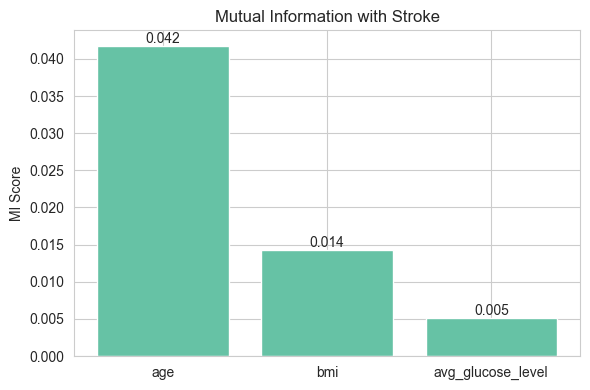

In [425]:
plt.figure(figsize=(6, 4))

bars = plt.bar(mi_df["feature"], mi_df["mutual_info"])

plt.title("Mutual Information with Stroke")
plt.ylabel("MI Score")

for bar, val in zip(bars, mi_df["mutual_info"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 7.12 Global summary of association with the target

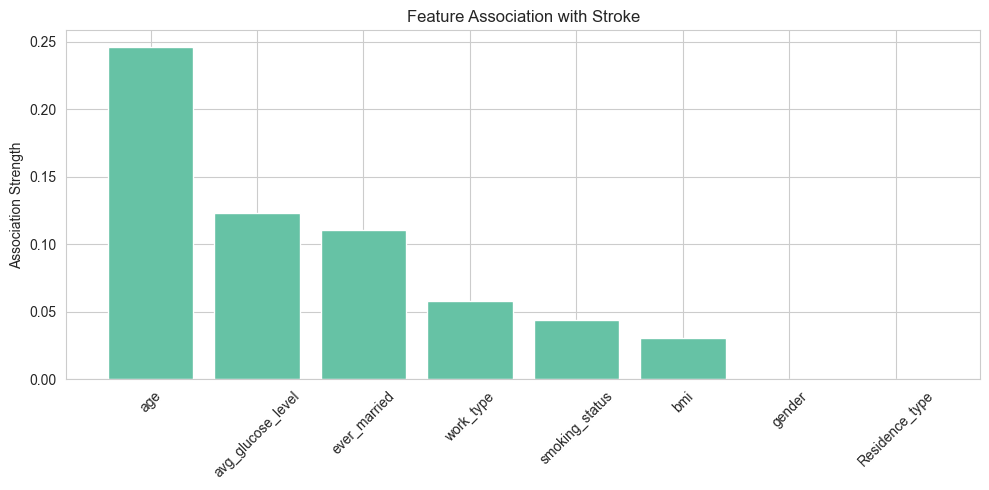

,feature,association_metric,metric_type
0,age,0.246029,Point-biserial
1,avg_glucose_level,0.123389,Point-biserial
1,ever_married,0.110280,Cramér's V
2,work_type,0.057578,Cramér's V
4,smoking_status,0.043780,Cramér's V
2,bmi,0.030358,Point-biserial
0,gender,0.000000,Cramér's V
3,Residence_type,0.000000,Cramér's V


In [426]:
num_summary = num_target_df[["feature", "point_biserial_corr"]].copy()
num_summary["association_metric"] = num_summary["point_biserial_corr"].abs()
num_summary["metric_type"] = "Point-biserial"

cat_summary = cat_target_df[["feature", "cramers_v"]].copy()
cat_summary = cat_summary.rename(columns={"cramers_v": "association_metric"})
cat_summary["metric_type"] = "Cramér's V"

global_summary = pd.concat([
    num_summary[["feature", "association_metric", "metric_type"]],
    cat_summary[["feature", "association_metric", "metric_type"]]
], axis=0).sort_values(by="association_metric", ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(global_summary["feature"], global_summary["association_metric"])
plt.title("Feature Association with Stroke")
plt.ylabel("Association Strength")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(global_summary)

## 8. Scaling for future models

In [427]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)

print("Scaling completed.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)

Scaling completed.
X_train_scaled shape: (3577, 11)
X_val_scaled shape: (1533, 11)


## 9. Summary

This notebook now contains the same analytical content as the original workflow, but presented in a more structured order:
1. Data loading and split.
2. EDA on the training set.
3. Focused missing-data and `"Unknown"` analysis.
4. Leakage-safe preprocessing.
5. Encoded and scaled matrices ready for modeling.
6. Correlation and association analysis using multiple complementary metrics.
